## 1.  Installation

In [35]:
import subprocess, sys

packages = [
    "mlflow", "imbalanced-learn",
    "sentence-transformers", "transformers", "torch",
    "scikit-learn", "pandas", "numpy",
    "matplotlib", "seaborn", "joblib"
]
for pkg in packages:
    print(f"  {pkg}...", end=" ")
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
    print("")
print("\n Toutes les dépendances installées")

  mlflow... 
  imbalanced-learn... 
  sentence-transformers... 
  transformers... 
  torch... 
  scikit-learn... 
  pandas... 
  numpy... 
  matplotlib... 
  seaborn... 
  joblib... 

 Toutes les dépendances installées


## 2.  Imports

In [36]:
import re, unicodedata, warnings, time, tempfile, os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, f1_score, precision_score, recall_score
)

from imblearn.over_sampling import RandomOverSampler

from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
import torch
import joblib

warnings.filterwarnings("ignore")
%matplotlib inline

print(" Imports OK")
print(f"   MLflow  : {mlflow.__version__}")
print(f"   PyTorch : {torch.__version__}")
print(f"   Device  : {'GPU ' if torch.cuda.is_available() else 'CPU'}")

 Imports OK
   MLflow  : 3.10.1
   PyTorch : 2.10.0+cu128
   Device  : GPU 


## 3. ️ Configuration MLflow

In [37]:
mlflow.set_tracking_uri("mlruns")
# mlflow.set_tracking_uri("http://localhost:5000")

EXPERIMENT_NAME = "sinistres_dual_stratified_balanced"
mlflow.set_experiment(EXPERIMENT_NAME)

exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
print(f" Expérience : '{EXPERIMENT_NAME}'")
print(f"   ID         : {exp.experiment_id}")
print(f"   URI        : {mlflow.get_tracking_uri()}")
print()
print(" Interface → terminal : mlflow ui → http://localhost:5000")

 Expérience : 'sinistres_dual_stratified_balanced'
   ID         : 648870267830998779
   URI        : mlruns

 Interface → terminal : mlflow ui → http://localhost:5000


## 4.  Données


In [38]:
df = pd.read_csv("canada_auto_claims_calls_french_raw.csv")

# ─────────────────────────────
# Labels classification
# ─────────────────────────────

LABELS_TYPE = sorted(df["type_sinistre"].unique())

LABELS_RESP = ["YES", "NO"]

LABELS_RESP_DISPLAY = [
    "Responsable",
    "Non responsable"
]

print(f"{len(df)} enregistrements | {df['type_sinistre'].nunique()} classes")
print()

vc_type = df["type_sinistre"].value_counts()
vc_resp = df["responsable"].value_counts()

print("=== Distribution TYPE DE SINISTRE ===")
print(vc_type.to_string())
print(f"Ratio max/min : {vc_type.max()/vc_type.min():.1f}x")

print()

print("=== Distribution RESPONSABLE ===")
print(vc_resp.to_string())
print(f"Ratio non/oui : {vc_resp['NO']/vc_resp['YES']:.1f}x")

50000 enregistrements | 6 classes

=== Distribution TYPE DE SINISTRE ===
type_sinistre
Collision                17193
Bris de glace             8601
Collision avec animal     6199
Vol                       6051
Vandalisme                6024
Feu                       5932
Ratio max/min : 2.9x

=== Distribution RESPONSABLE ===
responsable
NO     41501
YES     8499
Ratio non/oui : 4.9x


In [39]:
# Labels pour la tâche "responsable"
LABELS_RESP = ["YES", "NO"]

# Labels pour l'affichage dans les graphiques
LABELS_RESP_DISPLAY = [
    "Responsable",
    "Non responsable"
]

In [40]:
# Normaliser la colonne responsable
df["responsable"] = (
    df["responsable"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Sécuriser les valeurs
df = df[df["responsable"].isin(["YES", "NO"])]

## 5.  Nettoyage du texte

In [41]:
mots_bruit = [
    "bonjour","bonsoir","allo","allô","salut","euh","hum",
    "ben","pis","genre","alors"
]

def nettoyer_texte(texte):
    """Nettoyage complet pour TF-IDF"""
    if pd.isna(texte): return ""
    texte = texte.lower()
    texte = unicodedata.normalize("NFKD", texte).encode("ascii","ignore").decode("utf-8")
    for mot in mots_bruit:
        texte = re.sub(rf"\b{mot}\b", "", texte)
    texte = re.sub(r"[^a-z\s]", " ", texte)
    return re.sub(r"\s+", " ", texte).strip()

def nettoyer_texte_bert(texte):
    """Nettoyage léger — garde les accents pour CamemBERT/MiniLM"""
    if pd.isna(texte): return ""
    for mot in mots_bruit:
        texte = re.sub(rf"\b{mot}\b", "", texte, flags=re.IGNORECASE)
    return re.sub(r"\s+", " ", texte).strip()

df["transcription_clean"]      = df["transcription_appel_client"].apply(nettoyer_texte)
df["transcription_clean_bert"] = df["transcription_appel_client"].apply(nettoyer_texte_bert)
df = df[df["transcription_clean"].str.strip() != ""].reset_index(drop=True)

X_clean = df["transcription_clean"].values
X_bert  = df["transcription_clean_bert"].values
y_type  = df["type_sinistre"].values
y_resp  = df["responsable"].values

print(" Nettoyage terminé")
print(f"   Exemples valides : {len(df)}")

 Nettoyage terminé
   Exemples valides : 50000


## 6.  Visualisation du déséquilibre — Type ET Responsable
> On visualise les DEUX distributions pour bien comprendre le problème.

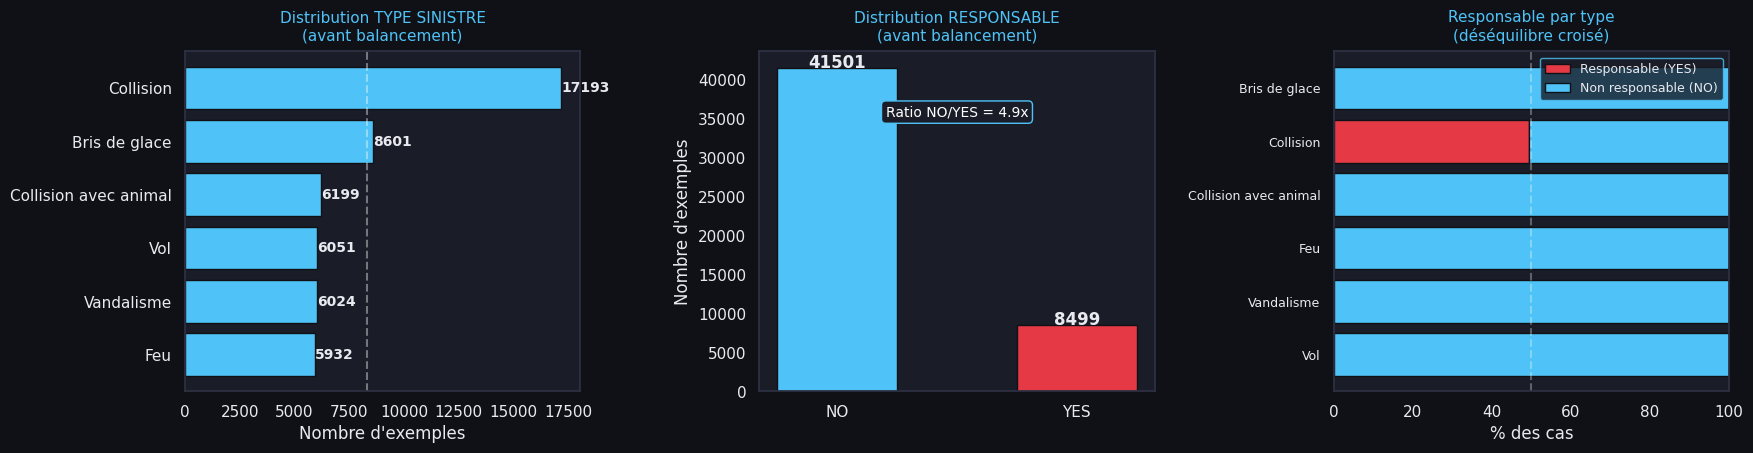

️  Problèmes détectés :
   Type sinistre  — ratio max/min : 2.9x
   Responsable    — ratio NO/YES : 4.9x

 Solutions appliquées :
   1. Label combiné type+resp pour stratification duale
   2. Oversampler SÉPARÉ pour chaque tâche
   3. class_weight='balanced' sur les deux classifieurs
   4. F1 Macro + recall_oui comme métriques principales


In [42]:
BG = "#0F1117"; CARD = "#1A1D27"; ACCENT = "#4FC3F7"; TEXT = "#E8EAF0"
PALETTE = {
    "collision":"#E63946","vol":"#2A9D8F","vandalisme":"#F4A261",
    "bris_vitre":"#457B9D","dommages_naturels":"#8AB17D",
    "incendie":"#E9C46A","delit_fuite":"#A8DADC","animal":"#C77DFF",
}
COLORS_MOD = ["#607D8B","#4FC3F7","#C77DFF"]

sns.set_theme(style="dark", rc={
    "axes.facecolor": CARD, "figure.facecolor": BG,
    "text.color": TEXT, "axes.labelcolor": TEXT,
    "xtick.color": TEXT, "ytick.color": TEXT,
    "axes.edgecolor": "#2D3142"
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG)

# A — Distribution type sinistre
vc = pd.Series(y_type).value_counts()
axes[0].barh(vc.index, vc.values,
             color=[PALETTE.get(k, ACCENT) for k in vc.index], edgecolor=BG)

for i, (idx, v) in enumerate(vc.items()):
    axes[0].text(v+0.1, i, str(v), va="center", color=TEXT,
                 fontsize=10, fontweight="bold")

axes[0].set_title("Distribution TYPE SINISTRE\n(avant balancement)",
                  color=ACCENT, fontsize=11, pad=8)

axes[0].set_xlabel("Nombre d'exemples")
axes[0].invert_yaxis()
axes[0].axvline(vc.mean(), color="white", linestyle="--", alpha=0.4)


# B — Distribution responsable
vc_r = pd.Series(y_resp).value_counts()

colors_resp = {
    "YES": "#E63946",
    "NO": "#4FC3F7"
}

axes[1].bar(vc_r.index, vc_r.values,
            color=[colors_resp.get(k,"gray") for k in vc_r.index],
            edgecolor=BG, width=0.5)

for i, (idx, v) in enumerate(vc_r.items()):
    axes[1].text(i, v+0.3, str(v),
                 ha="center", color=TEXT,
                 fontsize=12, fontweight="bold")

axes[1].set_title("Distribution RESPONSABLE\n(avant balancement)",
                  color=ACCENT, fontsize=11, pad=8)

axes[1].set_ylabel("Nombre d'exemples")

ratio = vc_r["NO"] / vc_r["YES"]

axes[1].text(
    0.5,
    max(vc_r.values)*0.85,
    f"Ratio NO/YES = {ratio:.1f}x",
    ha="center",
    color="white",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor=CARD, edgecolor=ACCENT)
)


# C — Distribution combinée type × responsable
df_cross = pd.crosstab(df["type_sinistre"], df["responsable"])
df_cross_pct = df_cross.div(df_cross.sum(axis=1), axis=0) * 100

y_pos = np.arange(len(df_cross_pct))

yes_v = df_cross_pct.get("YES", pd.Series(0, index=df_cross_pct.index)).values
no_v  = df_cross_pct.get("NO",  pd.Series(0, index=df_cross_pct.index)).values

axes[2].barh(y_pos, yes_v,
             color="#E63946",
             label="Responsable (YES)",
             edgecolor=BG)

axes[2].barh(y_pos, no_v,
             left=yes_v,
             color="#4FC3F7",
             label="Non responsable (NO)",
             edgecolor=BG)

axes[2].set_yticks(y_pos)
axes[2].set_yticklabels(df_cross_pct.index, fontsize=9)

axes[2].set_xlim(0, 100)
axes[2].set_xlabel("% des cas")

axes[2].set_title("Responsable par type\n(déséquilibre croisé)",
                  color=ACCENT, fontsize=11, pad=8)

axes[2].legend(fontsize=9, facecolor=CARD,
               edgecolor=ACCENT, labelcolor=TEXT)

axes[2].axvline(50, color="white", linestyle="--", alpha=0.3)
axes[2].invert_yaxis()

plt.tight_layout(pad=2)

plt.savefig(
    "desequilibre_dual.png",
    dpi=130,
    bbox_inches="tight",
    facecolor=BG
)

plt.show()

print("️  Problèmes détectés :")
print(f"   Type sinistre  — ratio max/min : {vc.max()/vc.min():.1f}x")
print(f"   Responsable    — ratio NO/YES : {ratio:.1f}x")
print()

print(" Solutions appliquées :")
print("   1. Label combiné type+resp pour stratification duale")
print("   2. Oversampler SÉPARÉ pour chaque tâche")
print("   3. class_weight='balanced' sur les deux classifieurs")
print("   4. F1 Macro + recall_oui comme métriques principales")

## 7.  Encodage des embeddings (MiniLM + CamemBERT)

In [43]:
# ── MiniLM ──────────────────────────────────────────────────
print("️  Chargement MiniLM (~120MB première fois)...")
t0 = time.time()
minilm_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
X_minilm = minilm_model.encode(X_bert.tolist(), show_progress_bar=True, batch_size=16)
print(f" MiniLM : {X_minilm.shape} en {time.time()-t0:.1f}s")

# ── CamemBERT ────────────────────────────────────────────────
print("\n️  Chargement CamemBERT (~500MB première fois)...")
t0 = time.time()
CAMEMBERT_NAME  = "camembert-base"
tokenizer_camem = AutoTokenizer.from_pretrained(CAMEMBERT_NAME)
model_camem     = AutoModel.from_pretrained(CAMEMBERT_NAME)
model_camem.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_camem.to(device)

def encode_camembert(textes, batch_size=8):
    all_emb = []
    for i in range(0, len(textes), batch_size):
        batch   = list(textes[i:i+batch_size])
        encoded = tokenizer_camem(batch, padding=True, truncation=True,
                                  max_length=128, return_tensors="pt").to(device)
        with torch.no_grad():
            out = model_camem(**encoded)
        mask = encoded["attention_mask"].unsqueeze(-1).expand(
                   out.last_hidden_state.size()).float()
        emb  = (torch.sum(out.last_hidden_state * mask, 1)
                / torch.clamp(mask.sum(1), min=1e-9))
        all_emb.append(emb.cpu().numpy())
        print(f"   Batch {i//batch_size+1}/{(len(textes)-1)//batch_size+1}", end="\r")
    print()
    return np.vstack(all_emb)

X_camembert = encode_camembert(X_bert.tolist())
print(f" CamemBERT : {X_camembert.shape} en {time.time()-t0:.1f}s")

️  Chargement MiniLM (~120MB première fois)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/3125 [00:00<?, ?it/s]

 MiniLM : (50000, 384) en 104.0s

️  Chargement CamemBERT (~500MB première fois)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Batch 6250/6250
 CamemBERT : (50000, 768) en 184.2s


In [44]:
# ── Label combiné pour stratification duale ─────────────────
y_combine = np.array([f"{t}__{r}" for t, r in zip(y_type, y_resp)])

print("=== Label combiné (type + responsable) ===")
vc_combine = pd.Series(y_combine).value_counts()
print(vc_combine.to_string())
print(f"\n{len(vc_combine)} combinaisons uniques")
print()

# Vérifier que chaque combinaison a assez d'exemples pour K-Fold
N_SPLITS = 5
min_count = vc_combine.min()
print(f"Minimum exemples par combinaison : {min_count}")
if min_count < N_SPLITS:
    print(f"️  Attention : {min_count} < {N_SPLITS} folds")
    print(f"   Solution   : réduire N_SPLITS à {min_count} ou ajouter des données")
    N_SPLITS = min_count
    print(f"   N_SPLITS ajusté automatiquement à {N_SPLITS}")
else:
    print(f" OK pour {N_SPLITS} folds")

LABELS_TYPE = sorted(set(y_type))
LABELS_RESP = ["YES", "NO"]
print(f"\nClasses type      : {LABELS_TYPE}")
print(f"Classes resp.      : {LABELS_RESP}")

=== Label combiné (type + responsable) ===
Collision__NO                8694
Bris de glace__NO            8601
Collision__YES               8499
Collision avec animal__NO    6199
Vol__NO                      6051
Vandalisme__NO               6024
Feu__NO                      5932

7 combinaisons uniques

Minimum exemples par combinaison : 5932
 OK pour 5 folds

Classes type      : ['Bris de glace', 'Collision', 'Collision avec animal', 'Feu', 'Vandalisme', 'Vol']
Classes resp.      : ['YES', 'NO']


## 9. ️ Fonctions utilitaires MLflow

In [49]:
# ── Métriques TYPE SINISTRE ─────────────────────────────────────────

def log_metriques_type(yt_true, yt_pred, prefix=""):
    """Log métriques type sinistre dans MLflow."""

    p = f"{prefix}_" if prefix else ""

    mlflow.log_metric(f"{p}type_accuracy",
                      accuracy_score(yt_true, yt_pred))

    mlflow.log_metric(f"{p}type_f1_macro",
                      f1_score(yt_true, yt_pred,
                               average="macro",
                               zero_division=0))

    mlflow.log_metric(f"{p}type_f1_weighted",
                      f1_score(yt_true, yt_pred,
                               average="weighted",
                               zero_division=0))

    mlflow.log_metric(f"{p}type_precision_macro",
                      precision_score(yt_true, yt_pred,
                                      average="macro",
                                      zero_division=0))

    mlflow.log_metric(f"{p}type_recall_macro",
                      recall_score(yt_true, yt_pred,
                                   average="macro",
                                   zero_division=0))

    # F1 par classe
    f1s = f1_score(
        yt_true,
        yt_pred,
        labels=LABELS_TYPE,
        average=None,
        zero_division=0
    )

    for lbl, score in zip(LABELS_TYPE, f1s):
        mlflow.log_metric(
            f"{p}type_f1_{lbl}",
            round(float(score), 4)
        )


# ── Métriques RESPONSABILITÉ ───────────────────────────────────────

def log_metriques_resp(yr_true, yr_pred, prefix=""):
    """
    Log métriques responsabilité dans MLflow.

    Priorité métier assurance :
    1️⃣ recall YES (ne pas rater un responsable)
    2️⃣ precision YES (ne pas accuser à tort)
    3️⃣ f1 YES (équilibre)
    """

    p = f"{prefix}_" if prefix else ""

    mlflow.log_metric(
        f"{p}resp_accuracy",
        accuracy_score(yr_true, yr_pred)
    )

    mlflow.log_metric(
        f"{p}resp_f1_macro",
        f1_score(yr_true, yr_pred,
                 average="macro",
                 zero_division=0)
    )

    mlflow.log_metric(
        f"{p}resp_f1_weighted",
        f1_score(yr_true, yr_pred,
                 average="weighted",
                 zero_division=0)
    )

    # métriques par classe
    f1_per = f1_score(
        yr_true,
        yr_pred,
        labels=LABELS_RESP,
        average=None,
        zero_division=0
    )

    prec_per = precision_score(
        yr_true,
        yr_pred,
        labels=LABELS_RESP,
        average=None,
        zero_division=0
    )

    rec_per = recall_score(
        yr_true,
        yr_pred,
        labels=LABELS_RESP,
        average=None,
        zero_division=0
    )

    for lbl, f1_v, p_v, r_v in zip(LABELS_RESP, f1_per, prec_per, rec_per):

        mlflow.log_metric(
            f"{p}resp_f1_{lbl}",
            round(float(f1_v), 4)
        )

        mlflow.log_metric(
            f"{p}resp_precision_{lbl}",
            round(float(p_v), 4)
        )

        mlflow.log_metric(
            f"{p}resp_recall_{lbl}",
            round(float(r_v), 4)
        )

    # métrique critique assurance
    recall_yes = rec_per[LABELS_RESP.index("YES")]

    mlflow.log_metric(
        f"{p}resp_false_negative_rate",
        round(float(1 - recall_yes), 4)
    )


# ── MATRICE CONFUSION TYPE SINISTRE ───────────────────────────────

def sauver_cm_type(yt_true, yt_pred, titre, filename):

    fig, ax = plt.subplots(figsize=(11, 7), facecolor=BG)

    cm = confusion_matrix(
        yt_true,
        yt_pred,
        labels=LABELS_TYPE
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=LABELS_TYPE,
        yticklabels=LABELS_TYPE,
        ax=ax,
        linewidths=0.5,
        linecolor=BG,
        cbar_kws={"shrink":0.8}
    )

    ax.set_title(titre, color=ACCENT, fontsize=13, pad=10)

    ax.set_xlabel("Prédit", fontsize=10)
    ax.set_ylabel("Réel", fontsize=10)

    ax.tick_params(axis="x", rotation=35, labelsize=8)
    ax.tick_params(axis="y", rotation=0, labelsize=8)

    plt.tight_layout()

    path = os.path.join(tempfile.gettempdir(), filename)

    fig.savefig(
        path,
        dpi=130,
        bbox_inches="tight",
        facecolor=BG
    )

    plt.close(fig)

    return path


# ── MATRICE CONFUSION RESPONSABLE ─────────────────────────────────

def sauver_cm_resp(yr_true, yr_pred, titre, filename):

    fig, ax = plt.subplots(figsize=(6, 5), facecolor=BG)

    cm = confusion_matrix(
        yr_true,
        yr_pred,
        labels=LABELS_RESP
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="RdYlGn",
        xticklabels=LABELS_RESP_DISPLAY,
        yticklabels=LABELS_RESP_DISPLAY,
        ax=ax,
        linewidths=0.5,
        linecolor=BG,
        cbar_kws={"shrink":0.8},
        annot_kws={"size":15}
    )

    ax.set_title(titre, color=ACCENT, fontsize=12, pad=10)

    ax.set_xlabel("Prédit", fontsize=10)
    ax.set_ylabel("Réel", fontsize=10)

    plt.tight_layout()

    path = os.path.join(tempfile.gettempdir(), filename)

    fig.savefig(
        path,
        dpi=130,
        bbox_inches="tight",
        facecolor=BG
    )

    plt.close(fig)

    return path


# ── COURBE ROC MULTICLASSE ───────────────────────────────────────

def sauver_roc(yt_true, yt_proba, clf_classes, titre, filename):

    fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)

    y_bin = label_binarize(
        yt_true,
        classes=LABELS_TYPE
    )

    for i, cls in enumerate(LABELS_TYPE):

        if cls not in clf_classes or y_bin[:,i].sum() == 0:
            continue

        ci = list(clf_classes).index(cls)

        fpr, tpr, _ = roc_curve(
            y_bin[:,i],
            yt_proba[:,ci]
        )

        ax.plot(
            fpr,
            tpr,
            lw=2,
            color=PALETTE.get(cls, ACCENT),
            label=f"{cls} (AUC={auc(fpr,tpr):.2f})"
        )

    ax.plot([0,1],[0,1],"--", color="gray", lw=1, alpha=0.5)

    ax.set_xlabel("Taux faux positifs", fontsize=9)
    ax.set_ylabel("Taux vrais positifs", fontsize=9)

    ax.set_title(titre, color=ACCENT, fontsize=12, pad=8)

    ax.legend(
        fontsize=8,
        loc="lower right",
        facecolor=CARD,
        edgecolor=ACCENT,
        labelcolor=TEXT,
        ncol=2
    )

    ax.set_xlim(0,1)
    ax.set_ylim(0,1.05)

    plt.tight_layout()

    path = os.path.join(tempfile.gettempdir(), filename)

    fig.savefig(
        path,
        dpi=130,
        bbox_inches="tight",
        facecolor=BG
    )

    plt.close(fig)

    return path


# ── RAPPORT TEXTE ────────────────────────────────────────────────

def sauver_rapport(yt_true, yt_pred, yr_true, yr_pred, filename):

    path = os.path.join(tempfile.gettempdir(), filename)

    with open(path, "w", encoding="utf-8") as f:

        f.write("=== RAPPORT TYPE DE SINISTRE ===\n")

        f.write(
            classification_report(
                yt_true,
                yt_pred,
                zero_division=0
            )
        )

        f.write("\n\n=== RAPPORT RESPONSABILITÉ ===\n")

        f.write(
            classification_report(
                yr_true,
                yr_pred,
                labels=LABELS_RESP,
                target_names=LABELS_RESP_DISPLAY,
                zero_division=0
            )
        )

    return path


print("Fonctions utilitaires prêtes")

Fonctions utilitaires prêtes


## 10.  Fonction Stratified K-Fold — Stratification Duale + Oversamplers Séparés
> **Point clé** : deux oversamplers indépendants — un pour type_sinistre, un pour responsable.  
> Cela garantit un balancement correct pour CHACUNE des deux tâches.

In [46]:
def run_kfold_dual(X_data, y_type_data, y_resp_data, y_combine_data,
                   make_clf_type_fn, make_clf_resp_fn,
                   needs_embedding=False, X_embed=None):
    """
    Stratified K-Fold avec stratification duale et oversamplers séparés.

    Stratification : sur y_combine (type + responsable simultanément)
    Balancement    : RandomOverSampler SÉPARÉ pour type et pour responsable
    """

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

    scores_par_fold = []

    yt_pred_all, yr_pred_all = [], []
    yt_true_all, yr_true_all = [], []
    yt_proba_all = []

    for fold_idx, (train_idx, test_idx) in enumerate(
            skf.split(X_data, y_combine_data)):

        print(f"  Fold {fold_idx+1}/{N_SPLITS}...", end=" ")

        yt_tr = y_type_data[train_idx]
        yr_tr = y_resp_data[train_idx]

        yt_te = y_type_data[test_idx]
        yr_te = y_resp_data[test_idx]

        if needs_embedding:

            X_tr = X_embed[train_idx]
            X_te = X_embed[test_idx]

            os_type = RandomOverSampler(random_state=42)
            X_tr_bal_type, yt_tr_bal = os_type.fit_resample(X_tr, yt_tr)

            os_resp = RandomOverSampler(random_state=42)
            X_tr_bal_resp, yr_tr_bal = os_resp.fit_resample(X_tr, yr_tr)

        else:

            tfidf = TfidfVectorizer(
                ngram_range=(1,2),
                max_features=5000,
                min_df=1,
                sublinear_tf=True,
                strip_accents="unicode"
            )

            X_tr_vec = tfidf.fit_transform(X_data[train_idx])
            X_te = tfidf.transform(X_data[test_idx])

            os_type = RandomOverSampler(random_state=42)
            X_tr_bal_type, yt_tr_bal = os_type.fit_resample(X_tr_vec, yt_tr)

            os_resp = RandomOverSampler(random_state=42)
            X_tr_bal_resp, yr_tr_bal = os_resp.fit_resample(X_tr_vec, yr_tr)

        clf_type = make_clf_type_fn()
        clf_resp = make_clf_resp_fn()

        clf_type.fit(X_tr_bal_type, yt_tr_bal)
        clf_resp.fit(X_tr_bal_resp, yr_tr_bal)

        yt_pred = clf_type.predict(X_te)
        yr_pred = clf_resp.predict(X_te)

        yt_proba = clf_type.predict_proba(X_te)

        acc_type = accuracy_score(yt_te, yt_pred)

        f1_macro = f1_score(
            yt_te, yt_pred,
            average="macro",
            zero_division=0
        )

        f1_w = f1_score(
            yt_te, yt_pred,
            average="weighted",
            zero_division=0
        )

        acc_resp = accuracy_score(yr_te, yr_pred)

        f1_resp_m = f1_score(
            yr_te, yr_pred,
            average="macro",
            zero_division=0
        )

        # métriques classe YES (responsable)

        rec_yes = recall_score(
            yr_te,
            yr_pred,
            labels=["YES"],
            average=None,
            zero_division=0
        )

        prec_yes = precision_score(
            yr_te,
            yr_pred,
            labels=["YES"],
            average=None,
            zero_division=0
        )

        f1_yes = f1_score(
            yr_te,
            yr_pred,
            labels=["YES"],
            average=None,
            zero_division=0
        )

        n_bal_type = (
            X_tr_bal_type.shape[0]
            if hasattr(X_tr_bal_type, "shape")
            else len(X_tr_bal_type)
        )

        n_bal_resp = (
            X_tr_bal_resp.shape[0]
            if hasattr(X_tr_bal_resp, "shape")
            else len(X_tr_bal_resp)
        )

        scores_par_fold.append({
            "fold": fold_idx + 1,
            "type_accuracy": acc_type,
            "type_f1_macro": f1_macro,
            "type_f1_weighted": f1_w,
            "resp_accuracy": acc_resp,
            "resp_f1_macro": f1_resp_m,
            "resp_recall_yes": float(rec_yes[0]) if len(rec_yes) > 0 else 0.0,
            "resp_prec_yes": float(prec_yes[0]) if len(prec_yes) > 0 else 0.0,
            "resp_f1_yes": float(f1_yes[0]) if len(f1_yes) > 0 else 0.0,
            "n_train_orig": len(train_idx),
            "n_bal_type": n_bal_type,
            "n_bal_resp": n_bal_resp,
            "n_test": len(test_idx),
        })

        yt_pred_all.extend(yt_pred)
        yr_pred_all.extend(yr_pred)

        yt_true_all.extend(yt_te)
        yr_true_all.extend(yr_te)

        yt_proba_all.append(yt_proba)

        print(
            f"acc_type={acc_type:.3f} | "
            f"f1_macro={f1_macro:.3f} | "
            f"acc_resp={acc_resp:.3f} | "
            f"recall_yes={float(rec_yes[0]) if len(rec_yes)>0 else 0:.3f}"
        )

    return (
        scores_par_fold,
        np.array(yt_pred_all),
        np.array(yr_pred_all),
        np.array(yt_true_all),
        np.array(yr_true_all),
        np.vstack(yt_proba_all)
    )


print(f" Fonction K-Fold duale prête | N_SPLITS = {N_SPLITS}")
print()
print("Points clés :")
print("   Stratification sur label COMBINÉ (type + responsable)")
print("   Oversampler SÉPARÉ pour type_sinistre")
print("   Oversampler SÉPARÉ pour responsable")
print("   recall_yes tracké à chaque fold")

 Fonction K-Fold duale prête | N_SPLITS = 5

Points clés :
   Stratification sur label COMBINÉ (type + responsable)
   Oversampler SÉPARÉ pour type_sinistre
   Oversampler SÉPARÉ pour responsable
   recall_yes tracké à chaque fold


## 11.  Run MLflow 1 — TF-IDF Dual Stratified

In [47]:
TFIDF_PARAMS = {
    "modele":            "TF-IDF + LogReg",
    "ngram_range":       "(1,2)",
    "max_features":      5000,
    "sublinear_tf":      True,
    "logreg_C":          1.0,
    "class_weight":      "balanced",
    "balancement":       "RandomOverSampler_SEPARE",
    "stratification":    "StratifiedKFold_label_COMBINE",
    "n_splits":          N_SPLITS,
    "dataset_size":      len(df),
}

with mlflow.start_run(run_name="TF-IDF_DualStratified") as run:

    mlflow.set_tags({
        "modele":          "TF-IDF + LogReg",
        "type_embedding":  "sparse_tfidf",
        "balancement":     "RandomOverSampler_SEPARE_par_tache",
        "validation":      f"StratifiedKFold_{N_SPLITS}_label_combine",
        "langue":          "français_canadien",
        "correction":      "stratification_duale_oversamplers_separes",
    })

    mlflow.log_params(TFIDF_PARAMS)

    t0 = time.time()

    print(f"TF-IDF — Stratified K-Fold dual ({N_SPLITS} folds)...")

    (scores_t,
     yt_pred_t, yr_pred_t,
     yt_true_t, yr_true_t,
     yt_proba_t) = run_kfold_dual(

        X_clean,
        y_type,
        y_resp,
        y_combine,

        make_clf_type_fn=lambda: LogisticRegression(
            max_iter=1000,
            random_state=42,
            C=1.0,
            class_weight="balanced"
        ),

        make_clf_resp_fn=lambda: LogisticRegression(
            max_iter=1000,
            random_state=42,
            C=1.0,
            class_weight="balanced"
        ),

        needs_embedding=False
    )

    t_tfidf = time.time() - t0

    df_t = pd.DataFrame(scores_t)

    # ─────────────────────────────────────────
    # métriques moyennes
    # ─────────────────────────────────────────

    for col in df_t.columns[1:]:

        if df_t[col].dtype in [float, np.float64]:

            mlflow.log_metric(
                f"mean_{col}",
                float(df_t[col].mean())
            )

            mlflow.log_metric(
                f"std_{col}",
                float(df_t[col].std())
            )

    # ─────────────────────────────────────────
    # métriques globales
    # ─────────────────────────────────────────

    log_metriques_type(yt_true_t, yt_pred_t)
    log_metriques_resp(yr_true_t, yr_pred_t)

    mlflow.log_metric(
        "training_time_sec",
        round(t_tfidf, 2)
    )

    # ─────────────────────────────────────────
    # métriques par fold
    # ─────────────────────────────────────────

    for s in scores_t:

        mlflow.log_metric(
            "fold_type_f1_macro",
            s["type_f1_macro"],
            step=s["fold"]
        )

        mlflow.log_metric(
            "fold_resp_f1_macro",
            s["resp_f1_macro"],
            step=s["fold"]
        )

        mlflow.log_metric(
            "fold_resp_recall_yes",
            s["resp_recall_yes"],
            step=s["fold"]
        )

        mlflow.log_metric(
            "fold_resp_f1_yes",
            s["resp_f1_yes"],
            step=s["fold"]
        )

    # ─────────────────────────────────────────
    # artefacts
    # ─────────────────────────────────────────

    p_cm_t = sauver_cm_type(
        yt_true_t,
        yt_pred_t,
        "Matrice Type — TF-IDF",
        "cm_type_tfidf.png"
    )

    p_cm_r = sauver_cm_resp(
        yr_true_t,
        yr_pred_t,
        "Matrice Responsable — TF-IDF",
        "cm_resp_tfidf.png"
    )

    p_roc = sauver_roc(
        yt_true_t,
        yt_proba_t,
        LABELS_TYPE,
        "ROC — TF-IDF",
        "roc_tfidf.png"
    )

    p_rep = sauver_rapport(
        yt_true_t,
        yt_pred_t,
        yr_true_t,
        yr_pred_t,
        "rapport_tfidf.txt"
    )

    p_csv = os.path.join(
        tempfile.gettempdir(),
        "kfold_tfidf.csv"
    )

    df_t.to_csv(p_csv, index=False)

    for p, folder in [
        (p_cm_t,"figures"),
        (p_cm_r,"figures"),
        (p_roc,"figures"),
        (p_rep,"rapports"),
        (p_csv,"kfold_scores")
    ]:

        mlflow.log_artifact(p, artifact_path=folder)

    # ─────────────────────────────────────────
    # modèle final
    # ─────────────────────────────────────────

    tfidf_f = TfidfVectorizer(
        ngram_range=(1,2),
        max_features=5000,
        min_df=1,
        sublinear_tf=True,
        strip_accents="unicode"
    )

    X_vec_all = tfidf_f.fit_transform(X_clean)

    os_t_f = RandomOverSampler(random_state=42)
    os_r_f = RandomOverSampler(random_state=42)

    X_bal_t, yt_bal = os_t_f.fit_resample(X_vec_all, y_type)
    X_bal_r, yr_bal = os_r_f.fit_resample(X_vec_all, y_resp)

    clf_tfidf_type_f = LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=1.0,
        class_weight="balanced"
    )

    clf_tfidf_resp_f = LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=1.0,
        class_weight="balanced"
    )

    clf_tfidf_type_f.fit(X_bal_t, yt_bal)
    clf_tfidf_resp_f.fit(X_bal_r, yr_bal)

    mlflow.sklearn.log_model(
        clf_tfidf_type_f,
        "modele_type",
        registered_model_name="tfidf_dual_type_sinistre"
    )

    mlflow.sklearn.log_model(
        clf_tfidf_resp_f,
        "modele_resp",
        registered_model_name="tfidf_dual_responsabilite"
    )

    RUN_ID_TFIDF = run.info.run_id


print(f"\nTF-IDF terminé en {t_tfidf:.1f}s | Run : {RUN_ID_TFIDF}")

print(
    df_t[
        ["fold","type_f1_macro","resp_f1_macro",
         "resp_recall_yes","resp_f1_yes"]
    ].to_string(index=False)
)

print(
    f"\nmean type_f1_macro  : {df_t['type_f1_macro'].mean():.3f} ± {df_t['type_f1_macro'].std():.3f}"
)

print(
    f"mean resp_recall_yes: {df_t['resp_recall_yes'].mean():.3f} ± {df_t['resp_recall_yes'].std():.3f}"
)

print(
    f"mean resp_f1_yes    : {df_t['resp_f1_yes'].mean():.3f} ± {df_t['resp_f1_yes'].std():.3f}"
)

TF-IDF — Stratified K-Fold dual (5 folds)...
  Fold 1/5... acc_type=1.000 | f1_macro=1.000 | acc_resp=1.000 | recall_yes=1.000
  Fold 2/5... acc_type=1.000 | f1_macro=1.000 | acc_resp=1.000 | recall_yes=1.000
  Fold 3/5... acc_type=1.000 | f1_macro=1.000 | acc_resp=1.000 | recall_yes=1.000
  Fold 4/5... acc_type=1.000 | f1_macro=1.000 | acc_resp=1.000 | recall_yes=1.000
  Fold 5/5... acc_type=1.000 | f1_macro=1.000 | acc_resp=1.000 | recall_yes=1.000


2026/03/12 01:36:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 01:36:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'tfidf_dual_type_sinistre'.
Created version '1' of model 'tfidf_dual_type_sinistre'.
2026/03/12 01:36:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 01:36:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The rec


TF-IDF terminé en 18.9s | Run : 9d9829fb1cae45368c7d0dfa4d266e3a
 fold  type_f1_macro  resp_f1_macro  resp_recall_yes  resp_f1_yes
    1            1.0            1.0              1.0          1.0
    2            1.0            1.0              1.0          1.0
    3            1.0            1.0              1.0          1.0
    4            1.0            1.0              1.0          1.0
    5            1.0            1.0              1.0          1.0

mean type_f1_macro  : 1.000 ± 0.000
mean resp_recall_yes: 1.000 ± 0.000
mean resp_f1_yes    : 1.000 ± 0.000


Successfully registered model 'tfidf_dual_responsabilite'.
Created version '1' of model 'tfidf_dual_responsabilite'.


## 12.  Run MLflow 2 — MiniLM Dual Stratified

In [50]:
MINILM_PARAMS = {
    "modele":            "MiniLM + LogReg",
    "embedding_model":   "paraphrase-multilingual-MiniLM-L12-v2",
    "embedding_dim":     384,
    "logreg_C":          1.0,
    "class_weight":      "balanced",
    "balancement":       "RandomOverSampler_SEPARE",
    "stratification":    "StratifiedKFold_label_COMBINE",
    "n_splits":          N_SPLITS,
    "dataset_size":      len(df),
}

with mlflow.start_run(run_name="MiniLM_DualStratified") as run:

    mlflow.set_tags({
        "modele":         "MiniLM + LogReg",
        "type_embedding": "dense_384d",
        "balancement":    "RandomOverSampler_SEPARE_par_tache",
        "validation":     f"StratifiedKFold_{N_SPLITS}_label_combine",
        "correction":     "stratification_duale_oversamplers_separes",
    })

    mlflow.log_params(MINILM_PARAMS)
    mlflow.log_metric("embedding_dim", 384)

    t0 = time.time()
    print(f"MiniLM — Stratified K-Fold dual ({N_SPLITS} folds)...")

    (scores_m, yt_pred_m, yr_pred_m,
     yt_true_m, yr_true_m, yt_proba_m) = run_kfold_dual(
        X_bert, y_type, y_resp, y_combine,
        make_clf_type_fn=lambda: LogisticRegression(
            max_iter=1000,
            random_state=42,
            C=1.0,
            class_weight="balanced"
        ),
        make_clf_resp_fn=lambda: LogisticRegression(
            max_iter=1000,
            random_state=42,
            C=1.0,
            class_weight="balanced"
        ),
        needs_embedding=True,
        X_embed=X_minilm
    )

    t_minilm = time.time() - t0
    df_m = pd.DataFrame(scores_m)

    # métriques moyennes
    for col in df_m.columns[1:]:
        if df_m[col].dtype in [float, np.float64]:
            mlflow.log_metric(f"mean_{col}", float(df_m[col].mean()))
            mlflow.log_metric(f"std_{col}",  float(df_m[col].std()))

    # métriques globales
    log_metriques_type(yt_true_m, yt_pred_m)
    log_metriques_resp(yr_true_m, yr_pred_m)

    mlflow.log_metric("training_time_sec", round(t_minilm, 2))

    # métriques par fold
    for s in scores_m:
        mlflow.log_metric("fold_type_f1_macro", s["type_f1_macro"], step=s["fold"])
        mlflow.log_metric("fold_resp_f1_macro", s["resp_f1_macro"], step=s["fold"])
        mlflow.log_metric("fold_resp_recall_yes", s["resp_recall_yes"], step=s["fold"])
        mlflow.log_metric("fold_resp_f1_yes", s["resp_f1_yes"], step=s["fold"])

    # artefacts
    p_cm_t = sauver_cm_type(
        yt_true_m, yt_pred_m,
        "Matrice Type — MiniLM",
        "cm_type_minilm.png"
    )

    p_cm_r = sauver_cm_resp(
        yr_true_m, yr_pred_m,
        "Matrice Responsable — MiniLM",
        "cm_resp_minilm.png"
    )

    p_roc = sauver_roc(
        yt_true_m,
        yt_proba_m,
        LABELS_TYPE,
        "ROC — MiniLM",
        "roc_minilm.png"
    )

    p_rep = sauver_rapport(
        yt_true_m,
        yt_pred_m,
        yr_true_m,
        yr_pred_m,
        "rapport_minilm.txt"
    )

    p_csv = os.path.join(tempfile.gettempdir(), "kfold_minilm.csv")
    df_m.to_csv(p_csv, index=False)

    for p, folder in [
        (p_cm_t,"figures"),
        (p_cm_r,"figures"),
        (p_roc,"figures"),
        (p_rep,"rapports"),
        (p_csv,"kfold_scores")
    ]:
        mlflow.log_artifact(p, artifact_path=folder)

    # modèle final sur tout le dataset
    os_t_m = RandomOverSampler(random_state=42)
    os_r_m = RandomOverSampler(random_state=42)

    X_bal_tm, yt_bal_m = os_t_m.fit_resample(X_minilm, y_type)
    X_bal_rm, yr_bal_m = os_r_m.fit_resample(X_minilm, y_resp)

    clf_minilm_type_f = LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=1.0,
        class_weight="balanced"
    )

    clf_minilm_resp_f = LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=1.0,
        class_weight="balanced"
    )

    clf_minilm_type_f.fit(X_bal_tm, yt_bal_m)
    clf_minilm_resp_f.fit(X_bal_rm, yr_bal_m)

    mlflow.sklearn.log_model(
        clf_minilm_type_f,
        "modele_type",
        registered_model_name="minilm_dual_type_sinistre"
    )

    mlflow.sklearn.log_model(
        clf_minilm_resp_f,
        "modele_resp",
        registered_model_name="minilm_dual_responsabilite"
    )

    RUN_ID_MINILM = run.info.run_id

print(f"\nMiniLM terminé en {t_minilm:.1f}s | Run : {RUN_ID_MINILM}")

print(
    df_m[
        ["fold","type_f1_macro","resp_f1_macro",
         "resp_recall_yes","resp_f1_yes"]
    ].to_string(index=False)
)

print(
    f"\nmean type_f1_macro  : {df_m['type_f1_macro'].mean():.3f} ± {df_m['type_f1_macro'].std():.3f}"
)

print(
    f"mean resp_recall_yes: {df_m['resp_recall_yes'].mean():.3f} ± {df_m['resp_recall_yes'].std():.3f}"
)

MiniLM — Stratified K-Fold dual (5 folds)...
  Fold 1/5... acc_type=1.000 | f1_macro=1.000 | acc_resp=1.000 | recall_yes=1.000
  Fold 2/5... acc_type=1.000 | f1_macro=1.000 | acc_resp=1.000 | recall_yes=1.000
  Fold 3/5... acc_type=1.000 | f1_macro=1.000 | acc_resp=1.000 | recall_yes=1.000
  Fold 4/5... acc_type=1.000 | f1_macro=1.000 | acc_resp=1.000 | recall_yes=1.000
  Fold 5/5... acc_type=1.000 | f1_macro=1.000 | acc_resp=1.000 | recall_yes=1.000


2026/03/12 01:40:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 01:40:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'minilm_dual_type_sinistre'.
Created version '1' of model 'minilm_dual_type_sinistre'.
2026/03/12 01:40:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 01:40:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The r


MiniLM terminé en 29.1s | Run : 20a4c6d85bc4409c9ebcd24cc53f38b7
 fold  type_f1_macro  resp_f1_macro  resp_recall_yes  resp_f1_yes
    1            1.0            1.0              1.0          1.0
    2            1.0            1.0              1.0          1.0
    3            1.0            1.0              1.0          1.0
    4            1.0            1.0              1.0          1.0
    5            1.0            1.0              1.0          1.0

mean type_f1_macro  : 1.000 ± 0.000
mean resp_recall_yes: 1.000 ± 0.000


Successfully registered model 'minilm_dual_responsabilite'.
Created version '1' of model 'minilm_dual_responsabilite'.


## 13.  Run MLflow 3 — CamemBERT Dual Stratified

In [51]:
CAMEMBERT_PARAMS = {
    "modele":            "CamemBERT + LogReg",
    "embedding_model":   "camembert-base",
    "embedding_dim":     768,
    "pooling":           "mean_pooling",
    "max_length":        128,
    "logreg_C":          1.0,
    "class_weight":      "balanced",
    "balancement":       "RandomOverSampler_SEPARE",
    "stratification":    "StratifiedKFold_label_COMBINE",
    "n_splits":          N_SPLITS,
    "dataset_size":      len(df),
}

with mlflow.start_run(run_name="CamemBERT_DualStratified") as run:

    mlflow.set_tags({
        "modele":         "CamemBERT + LogReg",
        "type_embedding": "dense_768d_bert_fr",
        "balancement":    "RandomOverSampler_SEPARE_par_tache",
        "validation":     f"StratifiedKFold_{N_SPLITS}_label_combine",
        "correction":     "stratification_duale_oversamplers_separes",
    })

    mlflow.log_params(CAMEMBERT_PARAMS)
    mlflow.log_metric("embedding_dim", 768)

    t0 = time.time()

    print(f"CamemBERT — Stratified K-Fold dual ({N_SPLITS} folds)...")

    (scores_c,
     yt_pred_c, yr_pred_c,
     yt_true_c, yr_true_c,
     yt_proba_c) = run_kfold_dual(
        X_bert, y_type, y_resp, y_combine,
        make_clf_type_fn=lambda: LogisticRegression(
            max_iter=1000,
            random_state=42,
            C=1.0,
            class_weight="balanced"
        ),
        make_clf_resp_fn=lambda: LogisticRegression(
            max_iter=1000,
            random_state=42,
            C=1.0,
            class_weight="balanced"
        ),
        needs_embedding=True,
        X_embed=X_camembert
    )

    t_camem = time.time() - t0

    df_c = pd.DataFrame(scores_c)

    # métriques moyennes
    for col in df_c.columns[1:]:
        if df_c[col].dtype in [float, np.float64]:
            mlflow.log_metric(f"mean_{col}", float(df_c[col].mean()))
            mlflow.log_metric(f"std_{col}", float(df_c[col].std()))

    # métriques globales
    log_metriques_type(yt_true_c, yt_pred_c)
    log_metriques_resp(yr_true_c, yr_pred_c)

    mlflow.log_metric("training_time_sec", round(t_camem, 2))

    # métriques par fold
    for s in scores_c:

        mlflow.log_metric(
            "fold_type_f1_macro",
            s["type_f1_macro"],
            step=s["fold"]
        )

        mlflow.log_metric(
            "fold_resp_f1_macro",
            s["resp_f1_macro"],
            step=s["fold"]
        )

        mlflow.log_metric(
            "fold_resp_recall_yes",
            s["resp_recall_yes"],
            step=s["fold"]
        )

        mlflow.log_metric(
            "fold_resp_f1_yes",
            s["resp_f1_yes"],
            step=s["fold"]
        )

    # artefacts
    p_cm_t = sauver_cm_type(
        yt_true_c, yt_pred_c,
        "Matrice Type — CamemBERT",
        "cm_type_camembert.png"
    )

    p_cm_r = sauver_cm_resp(
        yr_true_c, yr_pred_c,
        "Matrice Responsable — CamemBERT",
        "cm_resp_camembert.png"
    )

    p_roc = sauver_roc(
        yt_true_c,
        yt_proba_c,
        LABELS_TYPE,
        "ROC — CamemBERT",
        "roc_camembert.png"
    )

    p_rep = sauver_rapport(
        yt_true_c,
        yt_pred_c,
        yr_true_c,
        yr_pred_c,
        "rapport_camembert.txt"
    )

    p_csv = os.path.join(
        tempfile.gettempdir(),
        "kfold_camembert.csv"
    )

    df_c.to_csv(p_csv, index=False)

    for p, folder in [
        (p_cm_t,"figures"),
        (p_cm_r,"figures"),
        (p_roc,"figures"),
        (p_rep,"rapports"),
        (p_csv,"kfold_scores")
    ]:
        mlflow.log_artifact(p, artifact_path=folder)

    # modèle final
    os_t_c = RandomOverSampler(random_state=42)
    os_r_c = RandomOverSampler(random_state=42)

    X_bal_tc, yt_bal_c = os_t_c.fit_resample(X_camembert, y_type)
    X_bal_rc, yr_bal_c = os_r_c.fit_resample(X_camembert, y_resp)

    clf_camem_type_f = LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=1.0,
        class_weight="balanced"
    )

    clf_camem_resp_f = LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=1.0,
        class_weight="balanced"
    )

    clf_camem_type_f.fit(X_bal_tc, yt_bal_c)
    clf_camem_resp_f.fit(X_bal_rc, yr_bal_c)

    mlflow.sklearn.log_model(
        clf_camem_type_f,
        "modele_type",
        registered_model_name="camembert_dual_type_sinistre"
    )

    mlflow.sklearn.log_model(
        clf_camem_resp_f,
        "modele_resp",
        registered_model_name="camembert_dual_responsabilite"
    )

    RUN_ID_CAMEMBERT = run.info.run_id


print(f"\nCamemBERT terminé en {t_camem:.1f}s | Run : {RUN_ID_CAMEMBERT}")

print(
    df_c[
        ["fold","type_f1_macro","resp_f1_macro",
         "resp_recall_yes","resp_f1_yes"]
    ].to_string(index=False)
)

print(
    f"\nmean type_f1_macro  : {df_c['type_f1_macro'].mean():.3f} ± {df_c['type_f1_macro'].std():.3f}"
)

print(
    f"mean resp_recall_yes: {df_c['resp_recall_yes'].mean():.3f} ± {df_c['resp_recall_yes'].std():.3f}"
)

CamemBERT — Stratified K-Fold dual (5 folds)...
  Fold 1/5... acc_type=1.000 | f1_macro=1.000 | acc_resp=1.000 | recall_yes=1.000
  Fold 2/5... acc_type=1.000 | f1_macro=1.000 | acc_resp=1.000 | recall_yes=1.000
  Fold 3/5... acc_type=1.000 | f1_macro=1.000 | acc_resp=1.000 | recall_yes=1.000
  Fold 4/5... acc_type=1.000 | f1_macro=1.000 | acc_resp=1.000 | recall_yes=1.000
  Fold 5/5... acc_type=1.000 | f1_macro=1.000 | acc_resp=1.000 | recall_yes=1.000


2026/03/12 01:43:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 01:43:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'camembert_dual_type_sinistre'.
Created version '1' of model 'camembert_dual_type_sinistre'.
2026/03/12 01:43:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 01:43:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.


CamemBERT terminé en 86.0s | Run : 1fe3c72436d243b1921e196b68b6c1f9
 fold  type_f1_macro  resp_f1_macro  resp_recall_yes  resp_f1_yes
    1            1.0            1.0              1.0          1.0
    2            1.0            1.0              1.0          1.0
    3            1.0            1.0              1.0          1.0
    4            1.0            1.0              1.0          1.0
    5            1.0            1.0              1.0          1.0

mean type_f1_macro  : 1.000 ± 0.000
mean resp_recall_yes: 1.000 ± 0.000


Successfully registered model 'camembert_dual_responsabilite'.
Created version '1' of model 'camembert_dual_responsabilite'.


## 14.  Dashboard complet — Focus sur Responsable

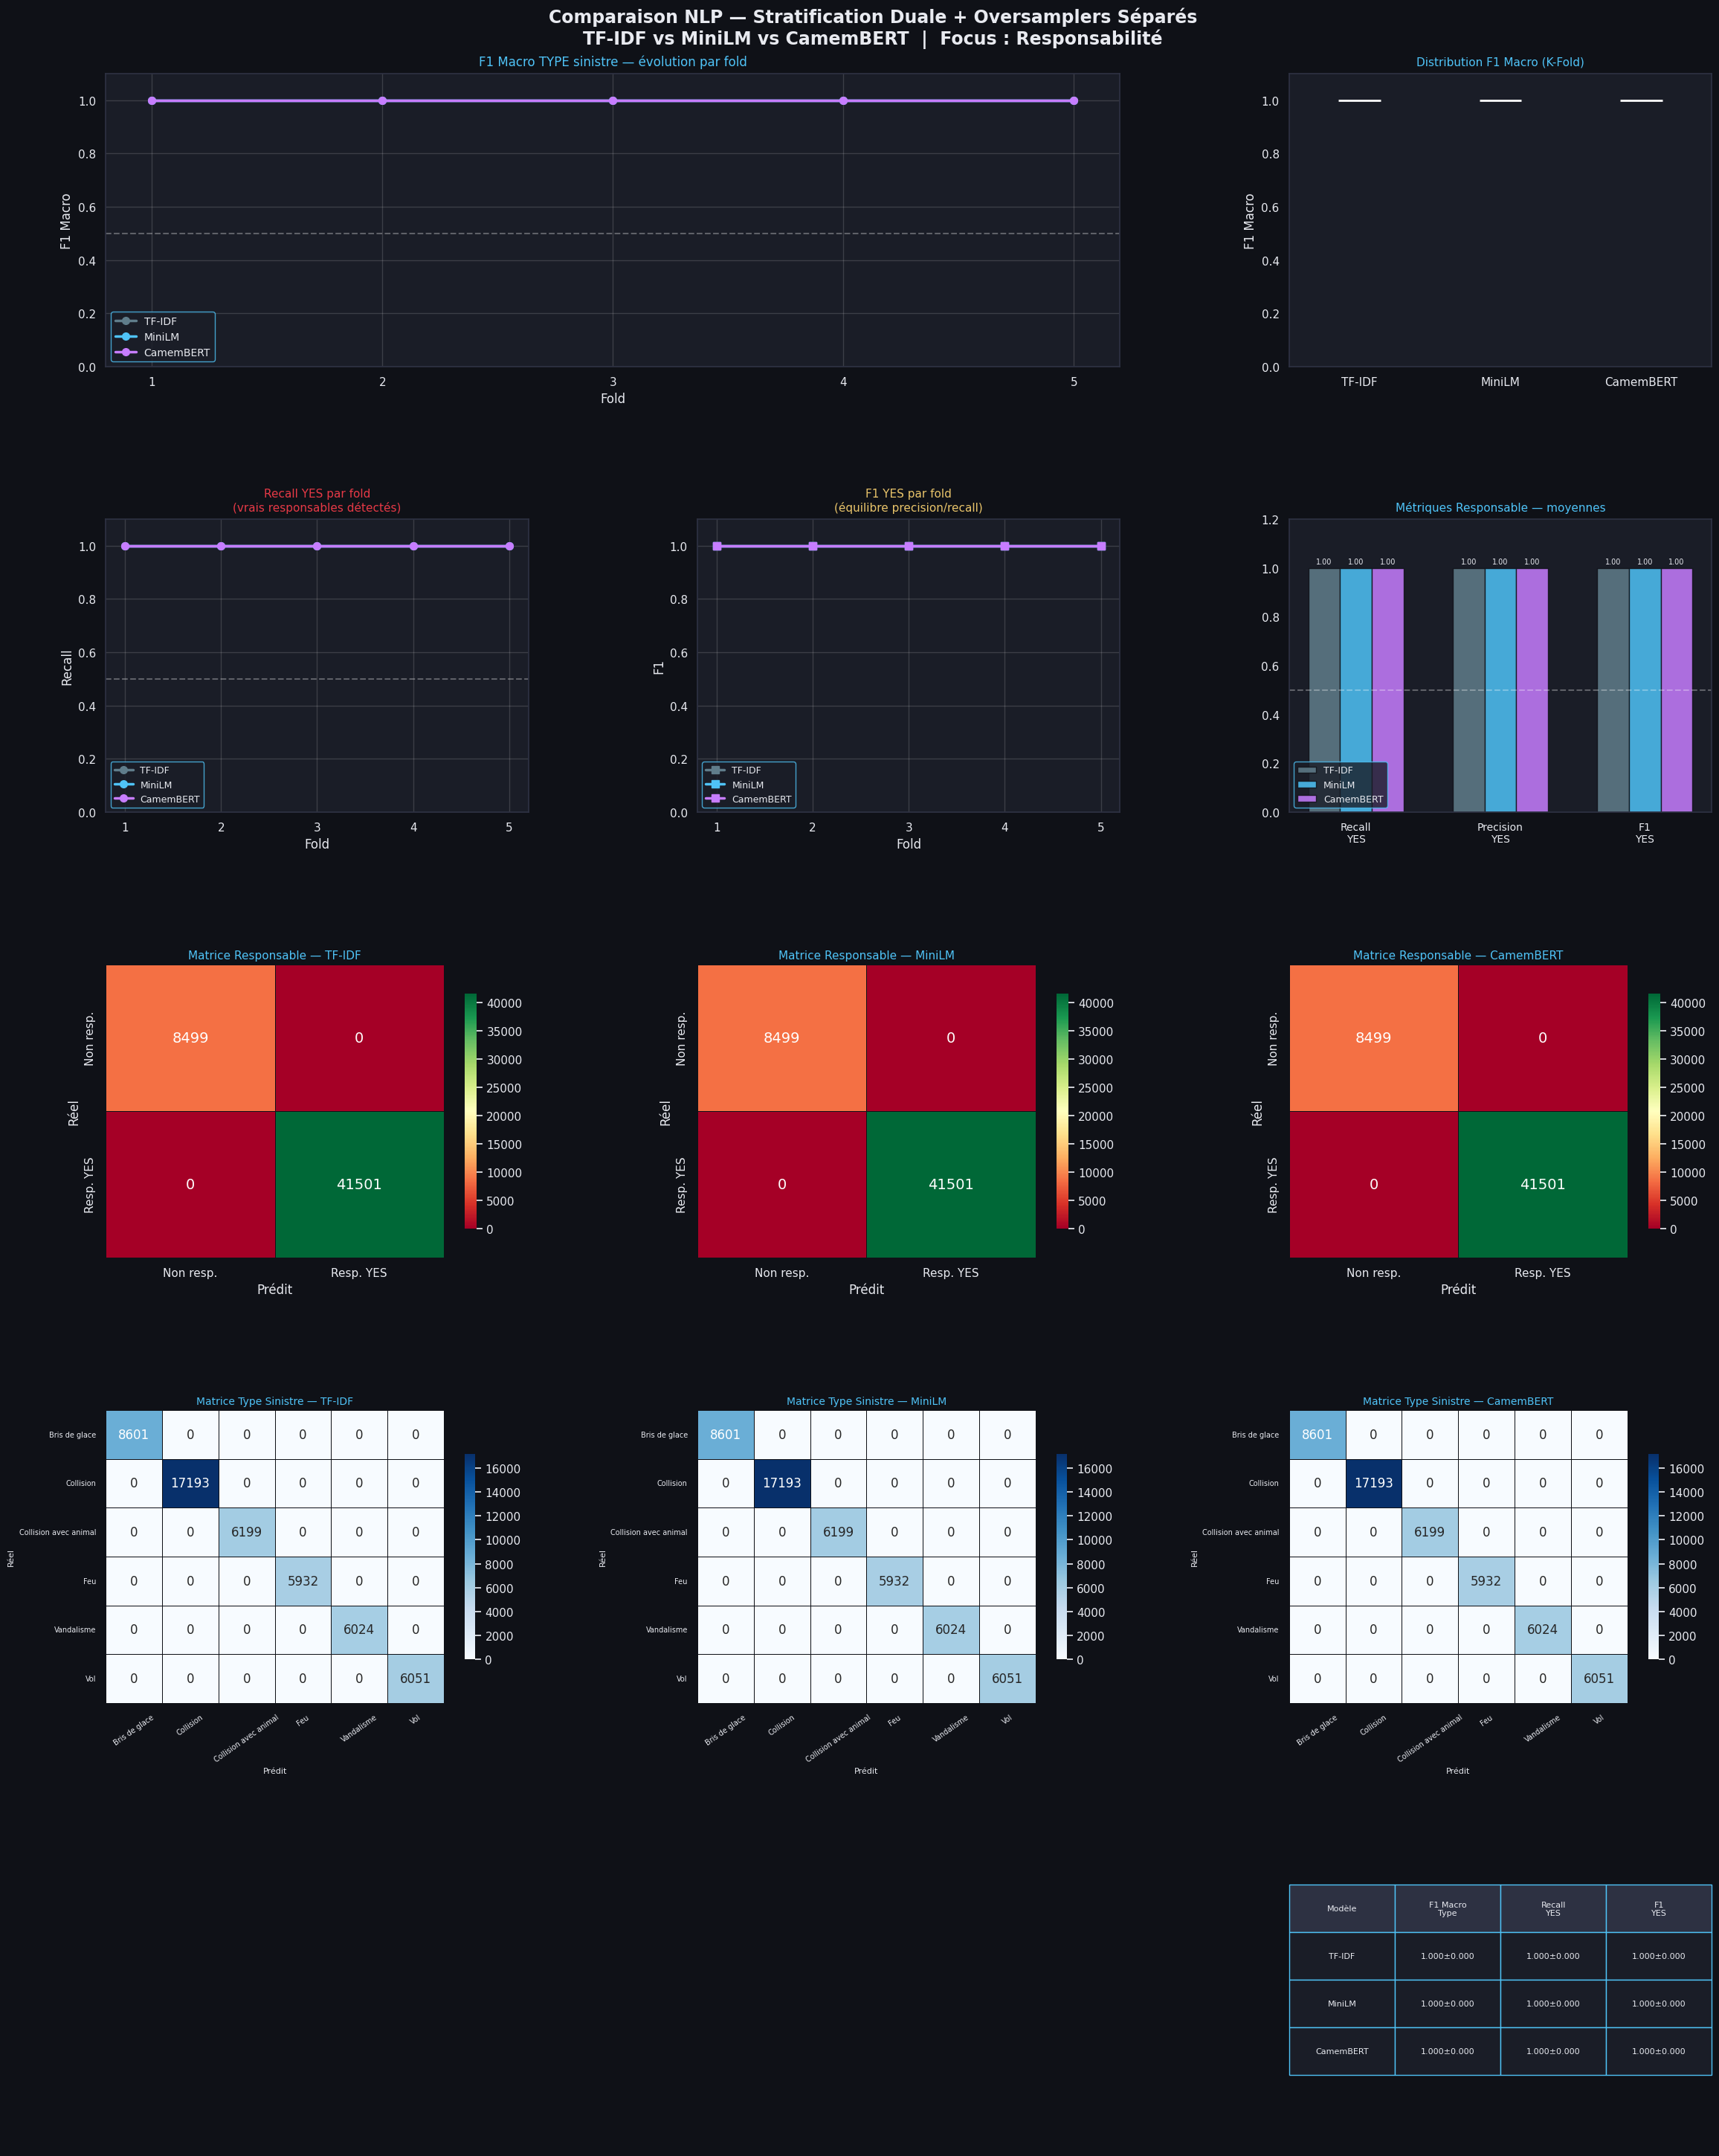

Dashboard généré
Dashboard enregistré dans les 3 runs MLflow


In [52]:
modeles_data = {
    "TF-IDF": {
        "scores": df_t,
        "pt": yt_pred_t,
        "pr": yr_pred_t,
        "tt": yt_true_t,
        "tr": yr_true_t,
        "proba": yt_proba_t,
        "color": "#607D8B"
    },
    "MiniLM": {
        "scores": df_m,
        "pt": yt_pred_m,
        "pr": yr_pred_m,
        "tt": yt_true_m,
        "tr": yr_true_m,
        "proba": yt_proba_m,
        "color": "#4FC3F7"
    },
    "CamemBERT": {
        "scores": df_c,
        "pt": yt_pred_c,
        "pr": yr_pred_c,
        "tt": yt_true_c,
        "tr": yr_true_c,
        "proba": yt_proba_c,
        "color": "#C77DFF"
    },
}

folds = list(range(1, N_SPLITS + 1))

fig = plt.figure(figsize=(24, 30), facecolor=BG)

fig.suptitle(
    "Comparaison NLP — Stratification Duale + Oversamplers Séparés\n"
    "TF-IDF vs MiniLM vs CamemBERT  |  Focus : Responsabilité",
    fontsize=17,
    color=TEXT,
    fontweight="bold",
    y=0.99
)

gs = gridspec.GridSpec(
    5, 3,
    figure=fig,
    hspace=0.52,
    wspace=0.40,
    left=0.07,
    right=0.97,
    top=0.96,
    bottom=0.03
)

x3 = np.arange(3)

# ─────────────────────────────────────────
# Ligne 0 : F1 Macro type par fold
# ─────────────────────────────────────────

ax0 = fig.add_subplot(gs[0, :2])

for nom, d in modeles_data.items():

    vals = d["scores"]["type_f1_macro"].tolist()

    ax0.plot(
        folds,
        vals,
        "o-",
        lw=2.5,
        ms=7,
        color=d["color"],
        label=nom
    )

ax0.set_xlabel("Fold")
ax0.set_ylabel("F1 Macro")

ax0.set_title(
    "F1 Macro TYPE sinistre — évolution par fold",
    color=ACCENT,
    fontsize=12,
    pad=8
)

ax0.set_xticks(folds)
ax0.set_ylim(0, 1.1)

ax0.legend(
    fontsize=10,
    facecolor=CARD,
    edgecolor=ACCENT,
    labelcolor=TEXT
)

ax0.axhline(0.5, color="white", linestyle="--", alpha=0.3)
ax0.grid(alpha=0.15)

# Boxplot F1 macro

ax0b = fig.add_subplot(gs[0, 2])

bp = ax0b.boxplot(
    [d["scores"]["type_f1_macro"].tolist() for d in modeles_data.values()],
    labels=list(modeles_data.keys()),
    patch_artist=True,
    medianprops={"color": "white", "linewidth": 2}
)

for patch, col in zip(bp["boxes"], [d["color"] for d in modeles_data.values()]):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)

ax0b.set_ylabel("F1 Macro")
ax0b.set_ylim(0, 1.1)

ax0b.set_title(
    "Distribution F1 Macro (K-Fold)",
    color=ACCENT,
    fontsize=11,
    pad=8
)

# ─────────────────────────────────────────
# Ligne 1 : métriques responsabilité
# ─────────────────────────────────────────

ax1a = fig.add_subplot(gs[1, 0])

for nom, d in modeles_data.items():

    vals = d["scores"]["resp_recall_yes"].tolist()

    ax1a.plot(
        folds,
        vals,
        "o-",
        lw=2.5,
        ms=7,
        color=d["color"],
        label=nom
    )

ax1a.set_xlabel("Fold")
ax1a.set_ylabel("Recall")

ax1a.set_title(
    "Recall YES par fold\n(vrais responsables détectés)",
    color="#E63946",
    fontsize=11,
    pad=8
)

ax1a.set_xticks(folds)
ax1a.set_ylim(0, 1.1)

ax1a.legend(
    fontsize=9,
    facecolor=CARD,
    edgecolor=ACCENT,
    labelcolor=TEXT
)

ax1a.axhline(0.5, color="white", linestyle="--", alpha=0.3)
ax1a.grid(alpha=0.15)

# F1 YES

ax1b = fig.add_subplot(gs[1, 1])

for nom, d in modeles_data.items():

    vals = d["scores"]["resp_f1_yes"].tolist()

    ax1b.plot(
        folds,
        vals,
        "s-",
        lw=2.5,
        ms=7,
        color=d["color"],
        label=nom
    )

ax1b.set_xlabel("Fold")
ax1b.set_ylabel("F1")

ax1b.set_title(
    "F1 YES par fold\n(équilibre precision/recall)",
    color="#E9C46A",
    fontsize=11,
    pad=8
)

ax1b.set_xticks(folds)
ax1b.set_ylim(0, 1.1)

ax1b.legend(
    fontsize=9,
    facecolor=CARD,
    edgecolor=ACCENT,
    labelcolor=TEXT
)

ax1b.grid(alpha=0.15)

# Bar chart métriques responsable

ax1c = fig.add_subplot(gs[1, 2])

metrics_resp = ["resp_recall_yes", "resp_prec_yes", "resp_f1_yes"]
labels_resp = ["Recall\nYES", "Precision\nYES", "F1\nYES"]

x_r = np.arange(len(metrics_resp))
width = 0.22

for i, (nom, d) in enumerate(modeles_data.items()):

    means = [d["scores"][m].mean() for m in metrics_resp]

    bars = ax1c.bar(
        x_r + i * width,
        means,
        width,
        color=d["color"],
        label=nom,
        edgecolor=BG,
        alpha=0.85
    )

    for b, v in zip(bars, means):

        ax1c.text(
            b.get_x() + b.get_width() / 2,
            v + 0.01,
            f"{v:.2f}",
            ha="center",
            va="bottom",
            fontsize=7,
            color=TEXT
        )

ax1c.set_xticks(x_r + width)
ax1c.set_xticklabels(labels_resp, fontsize=10)

ax1c.set_ylim(0, 1.2)

ax1c.set_title(
    "Métriques Responsable — moyennes",
    color=ACCENT,
    fontsize=11,
    pad=8
)

ax1c.legend(
    fontsize=9,
    facecolor=CARD,
    edgecolor=ACCENT,
    labelcolor=TEXT
)

ax1c.axhline(0.5, color="white", linestyle="--", alpha=0.3)

# ─────────────────────────────────────────
# Matrices confusion RESPONSABLE
# ─────────────────────────────────────────

for col_i, (nom, d) in enumerate(modeles_data.items()):

    ax = fig.add_subplot(gs[2, col_i])

    cm = confusion_matrix(
        d["tr"],
        d["pr"],
        labels=LABELS_RESP
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="RdYlGn",
        xticklabels=["Non resp.", "Resp. YES"],
        yticklabels=["Non resp.", "Resp. YES"],
        ax=ax,
        linewidths=0.5,
        linecolor=BG,
        cbar_kws={"shrink": 0.8},
        annot_kws={"size": 14}
    )

    ax.set_title(
        f"Matrice Responsable — {nom}",
        color=ACCENT,
        fontsize=11,
        pad=6
    )

    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")

# ─────────────────────────────────────────
# Matrices type sinistre
# ─────────────────────────────────────────

for col_i, (nom, d) in enumerate(modeles_data.items()):

    ax = fig.add_subplot(gs[3, col_i])

    cm = confusion_matrix(
        d["tt"],
        d["pt"],
        labels=LABELS_TYPE
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=LABELS_TYPE,
        yticklabels=LABELS_TYPE,
        ax=ax,
        linewidths=0.4,
        linecolor=BG,
        cbar_kws={"shrink": 0.7}
    )

    ax.set_title(
        f"Matrice Type Sinistre — {nom}",
        color=ACCENT,
        fontsize=10,
        pad=6
    )

    ax.set_xlabel("Prédit", fontsize=8)
    ax.set_ylabel("Réel", fontsize=8)

    ax.tick_params(axis="x", rotation=35, labelsize=7)
    ax.tick_params(axis="y", rotation=0, labelsize=7)

# ─────────────────────────────────────────
# Tableau résumé
# ─────────────────────────────────────────

ax4b = fig.add_subplot(gs[4, 2])
ax4b.axis("off")

table_rows = []

for nom, d in modeles_data.items():

    s = d["scores"]

    table_rows.append([
        nom,
        f"{s['type_f1_macro'].mean():.3f}±{s['type_f1_macro'].std():.3f}",
        f"{s['resp_recall_yes'].mean():.3f}±{s['resp_recall_yes'].std():.3f}",
        f"{s['resp_f1_yes'].mean():.3f}±{s['resp_f1_yes'].std():.3f}",
    ])

tbl = ax4b.table(
    cellText=table_rows,
    colLabels=["Modèle", "F1 Macro\nType", "Recall\nYES", "F1\nYES"],
    cellLoc="center",
    loc="center",
    bbox=[0, 0.25, 1, 0.65]
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(8)

for (r, c), cell in tbl.get_celld().items():

    cell.set_edgecolor(ACCENT)

    if r == 0:
        cell.set_facecolor("#2D3142")
    else:
        cell.set_facecolor(CARD)

    cell.set_text_props(color=TEXT)

# ─────────────────────────────────────────

dash_path = os.path.join(
    tempfile.gettempdir(),
    "dashboard_dual_stratified.png"
)

plt.savefig(
    dash_path,
    dpi=140,
    bbox_inches="tight",
    facecolor=BG
)

plt.show()

print("Dashboard généré")

for run_id in [RUN_ID_TFIDF, RUN_ID_MINILM, RUN_ID_CAMEMBERT]:

    with mlflow.start_run(run_id=run_id):
        mlflow.log_artifact(dash_path, artifact_path="figures")

print("Dashboard enregistré dans les 3 runs MLflow")

## 15. Tableau comparatif complet — Performance et temps de traitement

In [53]:
# Recuperer tous les runs depuis MLflow
runs_df = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    order_by=[
        "metrics.mean_resp_recall_yes DESC",
        "metrics.mean_type_f1_macro DESC"
    ]
)

runs_df = runs_df.dropna(subset=[
    "metrics.mean_resp_recall_yes",
    "metrics.mean_type_f1_macro"
])

# Colonnes a extraire
cols_map = {
    "tags.mlflow.runName":               "Modele",
    "metrics.training_time_sec":         "Temps_sec",
    "metrics.mean_type_accuracy":        "Acc_type_moy",
    "metrics.std_type_accuracy":         "Acc_type_std",
    "metrics.mean_type_f1_macro":        "F1_macro_moy",
    "metrics.std_type_f1_macro":         "F1_macro_std",
    "metrics.mean_type_f1_weighted":     "F1_weighted_moy",
    "metrics.mean_resp_accuracy":        "Acc_resp_moy",
    "metrics.std_resp_accuracy":         "Acc_resp_std",
    "metrics.mean_resp_f1_macro":        "F1_resp_macro_moy",
    "metrics.mean_resp_recall_yes":      "Recall_yes_moy",
    "metrics.std_resp_recall_yes":       "Recall_yes_std",
    "metrics.mean_resp_prec_yes":        "Precision_yes_moy",
    "metrics.mean_resp_f1_yes":          "F1_yes_moy",
    "metrics.std_resp_f1_yes":           "F1_yes_std",
    "metrics.embedding_dim":             "Dim_embedding",
}

tableau = runs_df[[c for c in cols_map if c in runs_df.columns]].copy()
tableau = tableau.rename(columns=cols_map)

# Formater les colonnes numeriques
fmt_cols = [c for c in tableau.columns if c not in ["Modele", "Temps_sec", "Dim_embedding"]]

for col in fmt_cols:
    if col in tableau.columns:
        tableau[col] = tableau[col].apply(
            lambda x: f"{x:.3f}" if pd.notna(x) else "N/A"
        )

if "Temps_sec" in tableau.columns:
    tableau["Temps_sec"] = tableau["Temps_sec"].apply(
        lambda x: f"{x:.1f}s" if pd.notna(x) else "N/A"
    )

if "Dim_embedding" in tableau.columns:
    tableau["Dim_embedding"] = tableau["Dim_embedding"].apply(
        lambda x: f"{int(x)}" if pd.notna(x) else "sparse"
    )

print("=" * 110)
print("TABLEAU COMPARATIF COMPLET — PERFORMANCE ET TEMPS DE TRAITEMENT")
print("=" * 110)
print(tableau.to_string(index=False))
print("=" * 110)

# Tableau resume lisible
print()
print("=" * 95)
print("RESUME — METRIQUES PRINCIPALES")
print(f"{'Modele':<30}  {'Temps':>8}  {'F1_macro':>10}  {'Acc_type':>10}  {'Acc_resp':>10}  {'Recall_yes':>12}  {'F1_yes':>8}")
print("-" * 95)

for _, row in runs_df.iterrows():

    nom     = row.get("tags.mlflow.runName", "N/A")
    temps   = row.get("metrics.training_time_sec", 0)
    f1m     = row.get("metrics.mean_type_f1_macro", 0)
    f1m_s   = row.get("metrics.std_type_f1_macro", 0)
    acc_t   = row.get("metrics.mean_type_accuracy", 0)
    acc_r   = row.get("metrics.mean_resp_accuracy", 0)
    rec_yes = row.get("metrics.mean_resp_recall_yes", 0)
    rec_s   = row.get("metrics.std_resp_recall_yes", 0)
    f1_yes  = row.get("metrics.mean_resp_f1_yes", 0)

    print(
        f"{nom:<30}  {temps:>7.1f}s"
        f"  {f1m:>7.3f}±{f1m_s:.3f}"
        f"  {acc_t:>9.3f}"
        f"  {acc_r:>9.3f}"
        f"  {rec_yes:>9.3f}±{rec_s:.3f}"
        f"  {f1_yes:>7.3f}"
    )

print("=" * 95)
print()

print("Colonnes :")
print("Temps        : temps total encodage + entrainement + validation K-Fold")
print("F1_macro     : F1 macro moyen sur type sinistre (mean ± std sur les folds)")
print("Acc_type     : accuracy moyenne sur type sinistre")
print("Acc_resp     : accuracy moyenne sur responsabilite")
print("Recall_yes   : rappel sur la classe responsable (mean ± std) — metrique prioritaire")
print("F1_yes       : F1 pour la classe responsable uniquement")

TABLEAU COMPARATIF COMPLET — PERFORMANCE ET TEMPS DE TRAITEMENT
                  Modele Temps_sec Acc_type_moy Acc_type_std F1_macro_moy F1_macro_std F1_weighted_moy Acc_resp_moy Acc_resp_std F1_resp_macro_moy Recall_yes_moy Recall_yes_std Precision_yes_moy F1_yes_moy F1_yes_std Dim_embedding
CamemBERT_DualStratified     86.0s        1.000        0.000        1.000        0.000           1.000        1.000        0.000             1.000          1.000          0.000             1.000      1.000      0.000           768
   MiniLM_DualStratified     29.1s        1.000        0.000        1.000        0.000           1.000        1.000        0.000             1.000          1.000          0.000             1.000      1.000      0.000           384
   MiniLM_DualStratified     23.1s        1.000        0.000        1.000        0.000           1.000        1.000        0.000             1.000          1.000          0.000             1.000      1.000      0.000           384
   TF-IDF_Du

## 16. Graphique performance et temps de traitement

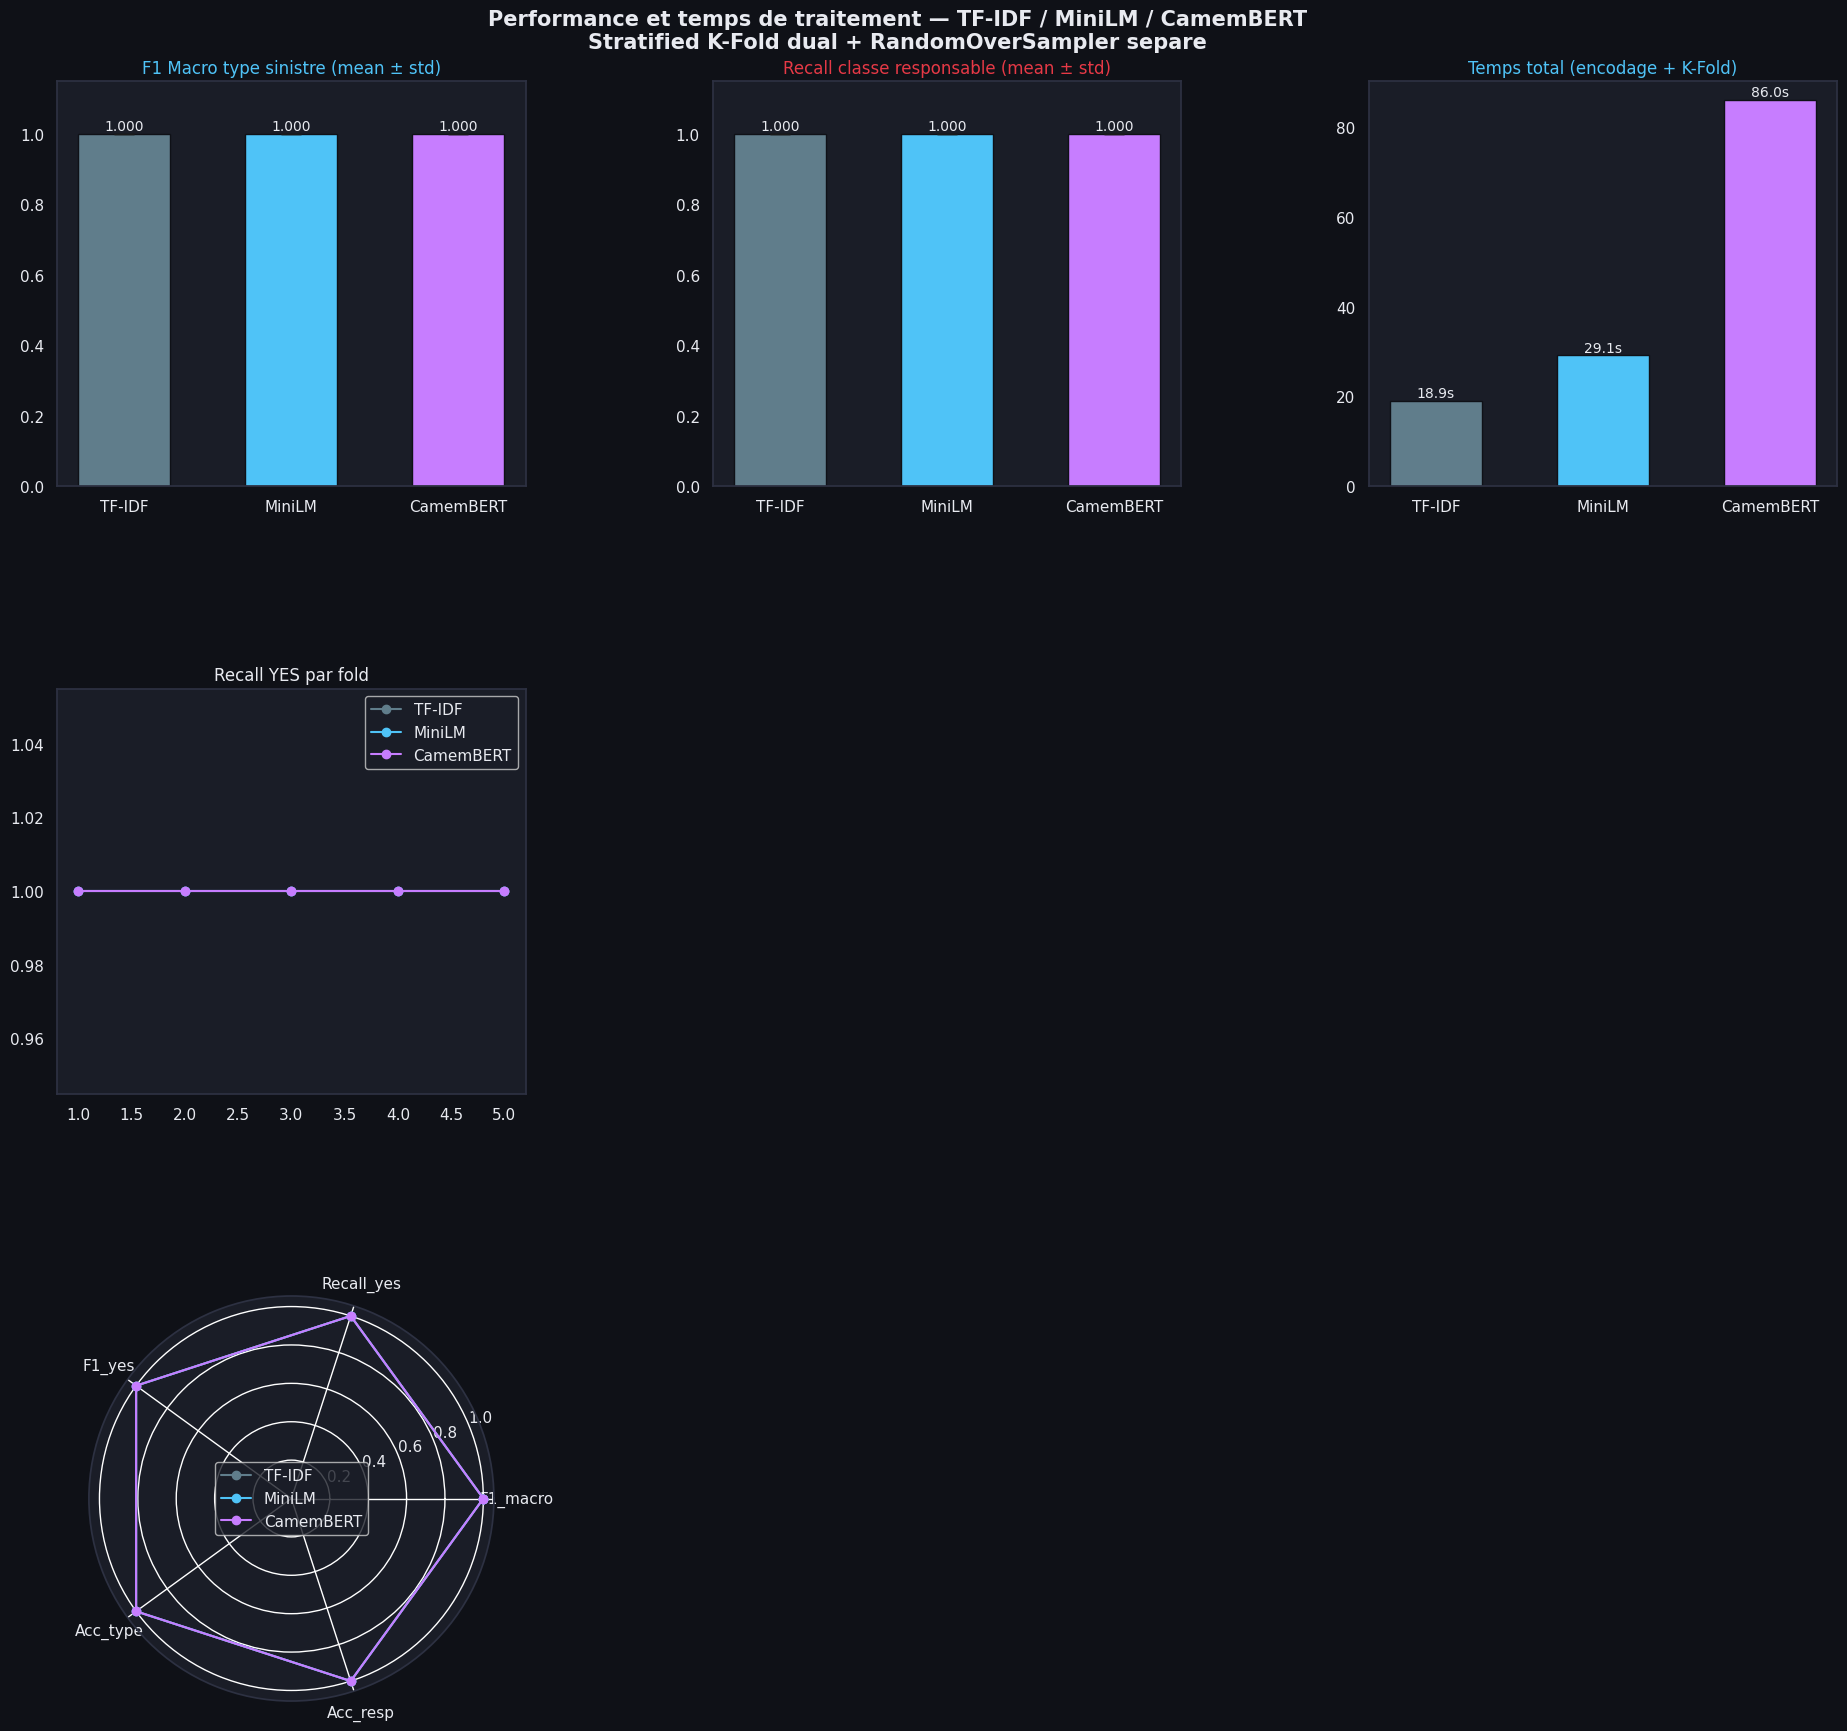

Graphique sauvegarde : graphique_performance_temps.png


In [54]:
import matplotlib.gridspec as gridspec

# Recuperer les donnees
noms_modeles  = ["TF-IDF", "MiniLM", "CamemBERT"]
couleurs      = ["#607D8B", "#4FC3F7", "#C77DFF"]
scores_list   = [df_t, df_m, df_c]
temps_list    = [t_tfidf, t_minilm, t_camem]

fig_perf = plt.figure(figsize=(20, 18), facecolor=BG)

fig_perf.suptitle(
    "Performance et temps de traitement — TF-IDF / MiniLM / CamemBERT\n"
    "Stratified K-Fold dual + RandomOverSampler separe",
    fontsize=15,
    color=TEXT,
    fontweight="bold",
    y=0.99
)

gs_p = gridspec.GridSpec(
    3, 3,
    figure=fig_perf,
    hspace=0.50,
    wspace=0.40,
    left=0.08,
    right=0.97,
    top=0.95,
    bottom=0.05
)

x3 = np.arange(3)
w  = 0.55

# ─────────────────────────────────────
# Ligne 0 : F1 macro / Recall YES / Temps
# ─────────────────────────────────────

ax_f1 = fig_perf.add_subplot(gs_p[0, 0])

means = [s["type_f1_macro"].mean() for s in scores_list]
stds  = [s["type_f1_macro"].std() for s in scores_list]

bars = ax_f1.bar(
    x3, means,
    yerr=stds,
    capsize=7,
    color=couleurs,
    edgecolor=BG,
    width=w
)

for b, v, sd in zip(bars, means, stds):

    ax_f1.text(
        b.get_x() + b.get_width()/2,
        v + sd + 0.01,
        f"{v:.3f}",
        ha="center",
        fontsize=10,
        color=TEXT
    )

ax_f1.set_xticks(x3)
ax_f1.set_xticklabels(noms_modeles)
ax_f1.set_ylim(0, 1.15)

ax_f1.set_title(
    "F1 Macro type sinistre (mean ± std)",
    color=ACCENT
)

# ─────────────────────────────────────
# Recall YES
# ─────────────────────────────────────

ax_rec = fig_perf.add_subplot(gs_p[0, 1])

means_r = [s["resp_recall_yes"].mean() for s in scores_list]
stds_r  = [s["resp_recall_yes"].std() for s in scores_list]

bars_r = ax_rec.bar(
    x3, means_r,
    yerr=stds_r,
    capsize=7,
    color=couleurs,
    edgecolor=BG,
    width=w
)

for b, v, sd in zip(bars_r, means_r, stds_r):

    ax_rec.text(
        b.get_x()+b.get_width()/2,
        v+sd+0.01,
        f"{v:.3f}",
        ha="center",
        fontsize=10,
        color=TEXT
    )

ax_rec.set_xticks(x3)
ax_rec.set_xticklabels(noms_modeles)

ax_rec.set_ylim(0, 1.15)

ax_rec.set_title(
    "Recall classe responsable (mean ± std)",
    color="#E63946"
)

# ─────────────────────────────────────
# Temps
# ─────────────────────────────────────

ax_t = fig_perf.add_subplot(gs_p[0, 2])

bars_t = ax_t.bar(
    x3,
    temps_list,
    color=couleurs,
    edgecolor=BG,
    width=w
)

for b, v in zip(bars_t, temps_list):

    ax_t.text(
        b.get_x()+b.get_width()/2,
        v + max(temps_list)*0.01,
        f"{v:.1f}s",
        ha="center",
        fontsize=10,
        color=TEXT
    )

ax_t.set_xticks(x3)
ax_t.set_xticklabels(noms_modeles)

ax_t.set_title(
    "Temps total (encodage + K-Fold)",
    color=ACCENT
)

# ─────────────────────────────────────
# Ligne 1 : Evolution par fold
# ─────────────────────────────────────

folds = list(range(1, N_SPLITS+1))

ax_fold_rec = fig_perf.add_subplot(gs_p[1, 0])

for nom, s, col in zip(noms_modeles, scores_list, couleurs):

    ax_fold_rec.plot(
        folds,
        s["resp_recall_yes"].tolist(),
        "o-",
        color=col,
        label=nom
    )

ax_fold_rec.set_title("Recall YES par fold")
ax_fold_rec.legend()

# ─────────────────────────────────────
# Radar chart
# ─────────────────────────────────────

ax_radar = fig_perf.add_subplot(gs_p[2, 0], polar=True)

categories = [
    "F1_macro",
    "Recall_yes",
    "F1_yes",
    "Acc_type",
    "Acc_resp"
]

angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

for nom, s, col in zip(noms_modeles, scores_list, couleurs):

    values = [
        s["type_f1_macro"].mean(),
        s["resp_recall_yes"].mean(),
        s["resp_f1_yes"].mean(),
        s["type_accuracy"].mean(),
        s["resp_accuracy"].mean(),
    ]

    values += values[:1]

    ax_radar.plot(
        angles,
        values,
        "o-",
        color=col,
        label=nom
    )

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories)

ax_radar.legend()

# ─────────────────────────────────────

plt.savefig(
    "graphique_performance_temps.png",
    dpi=140,
    bbox_inches="tight",
    facecolor=BG
)

plt.show()

print("Graphique sauvegarde : graphique_performance_temps.png")

## 17. Predictions sur nouveaux appels — 3 modeles cote a cote

In [58]:
nouveaux_appels = [

    # responsabilité probable
    "Je conduisais un peu vite sous la pluie et j'ai perdu le controle dans un virage avant de heurter une autre voiture.",

    "En changeant de voie je n'avais pas vu un vehicule dans mon angle mort et je l'ai accroche.",

    "Je regardais mon GPS et j'ai freine trop tard, ce qui a cause une collision avec la voiture devant moi.",

    "J'ai recule de mon stationnement et je n'ai pas vu une voiture qui arrivait derriere.",

    "Je suis passe a l'orange mais la voiture qui arrivait a gauche a freine brusquement et on s'est percutes.",

    # responsabilité incertaine
    "Je circulais normalement quand une voiture a freine brusquement devant moi et je n'ai pas pu eviter la collision.",

    "Un autre conducteur a change de voie soudainement devant moi et je l'ai touche en freinant.",

    "Je traversais une intersection lorsque l'autre vehicule est arrive tres vite et nous nous sommes percutes.",

    "Je roulais sur l'autoroute quand un camion a perdu un objet qui a frappe ma voiture.",

    "Une voiture m'a coupe la route dans un rond-point et il y a eu un accrochage.",

    # non responsable
    "Ma voiture etait stationnee dans la rue et quelqu'un l'a percute pendant la nuit.",

    "Je conduisais normalement quand un conducteur a grille un stop et m'a percute sur le cote.",

    "Un autre vehicule est sorti d'un stationnement sans regarder et m'a frappe.",

    "Un conducteur venant en sens inverse a devie dans ma voie et a percute ma voiture.",

    "Un arbre est tombe sur ma voiture pendant une tempete alors qu'elle etait stationnee.",

    # cas tres difficiles
    "Je roulais dans un parking et une voiture sortait en meme temps que moi, on s'est touches en reculant.",

    "Je me suis engage dans l'intersection au feu vert mais un autre vehicule tournait a gauche et nous nous sommes percutes.",

    "Je roulais dans un embouteillage et la voiture derriere moi m'a pousse contre celle devant.",

    "Je changeais de voie quand une moto est apparue entre les voitures et il y a eu un accrochage.",

    "Je sortais d'un stationnement pendant qu'une voiture reculait aussi et nous sommes entres en collision."
]
tfidf_pred = TfidfVectorizer(ngram_range=(1,2), max_features=5000,
                              min_df=1, sublinear_tf=True, strip_accents="unicode")
tfidf_pred.fit(X_clean)

print(f"{'Appel (50 chars)':<52} | {'TF-IDF':<22} | {'MiniLM':<22} | {'CamemBERT':<22}")
print("-" * 128)

for appel in nouveaux_appels:
    c_clean = nettoyer_texte(appel)
    c_bert  = nettoyer_texte_bert(appel)

    vec   = tfidf_pred.transform([c_clean])
    t_t   = clf_tfidf_type_f.predict(vec)[0]
    r_t   = clf_tfidf_resp_f.predict(vec)[0]
    l_t   = f"{t_t[:12]} [{r_t.upper()}]"

    emb_m = minilm_model.encode([c_bert])
    t_m   = clf_minilm_type_f.predict(emb_m)[0]
    r_m   = clf_minilm_resp_f.predict(emb_m)[0]
    l_m   = f"{t_m[:12]} [{r_m.upper()}]"

    emb_c = encode_camembert([c_bert])
    t_c   = clf_camem_type_f.predict(emb_c)[0]
    r_c   = clf_camem_resp_f.predict(emb_c)[0]
    l_c   = f"{t_c[:12]} [{r_c.upper()}]"

    print(f"{appel[:50]:<52} | {l_t:<22} | {l_m:<22} | {l_c:<22}")

print()
print("Legende : [OUI] = responsable  |  [NON] = non responsable")


Appel (50 chars)                                     | TF-IDF                 | MiniLM                 | CamemBERT             
--------------------------------------------------------------------------------------------------------------------------------
   Batch 1/1
Je conduisais un peu vite sous la pluie et j'ai pe   | Collision [NO]         | Collision [YES]        | Collision [NO]        
   Batch 1/1
En changeant de voie je n'avais pas vu un vehicule   | Collision [NO]         | Collision [YES]        | Collision av [NO]     
   Batch 1/1
Je regardais mon GPS et j'ai freine trop tard, ce    | Collision [NO]         | Collision [YES]        | Collision av [NO]     
   Batch 1/1
J'ai recule de mon stationnement et je n'ai pas vu   | Vandalisme [NO]        | Collision [NO]         | Collision av [NO]     
   Batch 1/1
Je suis passe a l'orange mais la voiture qui arriv   | Collision [NO]         | Collision [NO]         | Collision av [NO]     
   Batch 1/1
Je circulais normalement 

## 18. Selection et enregistrement du meilleur modele

In [79]:
from mlflow.tracking import MlflowClient
import mlflow
import os
import json

client = MlflowClient()

# Recuperer tous les runs
runs_df_sel = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME]
)

# Filtrer uniquement les runs MiniLM
runs_df_sel = runs_df_sel[
    runs_df_sel["tags.mlflow.runName"].str.contains("MiniLM", na=False)
]

if runs_df_sel.empty:
    raise Exception("Aucun run MiniLM trouvé dans MLflow.")

# Trier selon la metrique prioritaire
runs_df_sel = runs_df_sel.sort_values(
    by=[
        "metrics.mean_resp_recall_oui",
        "metrics.mean_type_f1_macro"
    ],
    ascending=False
)

print("=" * 70)
print("CLASSEMENT DES RUNS MiniLM")
print("=" * 70)

for rank, (_, row) in enumerate(runs_df_sel.iterrows(), 1):

    recall = row.get("metrics.mean_resp_recall_oui", 0)
    f1     = row.get("metrics.mean_type_f1_macro", 0)

    print(
        f"#{rank} "
        f"{row['tags.mlflow.runName']:<30}"
        f" recall_oui={recall:.3f}"
        f" f1_macro={f1:.3f}"
    )

print("=" * 70)

# Selection du meilleur MiniLM
best_run = runs_df_sel.iloc[0]

best_run_id   = best_run["run_id"]
best_run_name = best_run["tags.mlflow.runName"]

print("\nMeilleur MiniLM :", best_run_name)
print("Run ID :", best_run_id)

# Dossier de sauvegarde
save_dir = "modele_final_minilm"
os.makedirs(save_dir, exist_ok=True)

print("\nTéléchargement des artefacts MLflow...")

client.download_artifacts(
    best_run_id,
    "modele_type",
    save_dir
)

client.download_artifacts(
    best_run_id,
    "modele_resp",
    save_dir
)

# Sauvegarde metadata
metadata = {
    "model": "MiniLM",
    "run_id": best_run_id,
    "run_name": best_run_name,
    "recall_oui": float(best_run["metrics.mean_resp_recall_oui"]),
    "f1_macro_type": float(best_run["metrics.mean_type_f1_macro"])
}

with open(os.path.join(save_dir, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

print("\nMiniLM enregistré dans :", save_dir)

CLASSEMENT DES RUNS MiniLM
#1 MiniLM_DualStratified          recall_oui=nan f1_macro=1.000
#2 MiniLM_DualStratified          recall_oui=nan f1_macro=1.000

Meilleur MiniLM : MiniLM_DualStratified
Run ID : 20a4c6d85bc4409c9ebcd24cc53f38b7

Téléchargement des artefacts MLflow...



MiniLM enregistré dans : modele_final_minilm


In [80]:
import joblib

print("Chargement depuis MLflow...")

uri_type = f"runs:/{best_run_id}/modele_type"
uri_resp = f"runs:/{best_run_id}/modele_resp"

best_clf_type = mlflow.sklearn.load_model(uri_type)
best_clf_resp = mlflow.sklearn.load_model(uri_resp)

print("Modele type charge :", type(best_clf_type).__name__)
print("Modele resp charge :", type(best_clf_resp).__name__)

os.makedirs("best_model", exist_ok=True)

joblib.dump(best_clf_type, "best_model/best_clf_type_sinistre.pkl")
joblib.dump(best_clf_resp, "best_model/best_clf_responsabilite.pkl")

print("Modeles sauvegardes dans best_model/")

Chargement depuis MLflow...


Modele type charge : LogisticRegression
Modele resp charge : LogisticRegression
Modeles sauvegardes dans best_model/


In [81]:
runs = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME])
print(runs[["run_id","tags.mlflow.runName"]])

                             run_id       tags.mlflow.runName
0  1fe3c72436d243b1921e196b68b6c1f9  CamemBERT_DualStratified
1  20a4c6d85bc4409c9ebcd24cc53f38b7     MiniLM_DualStratified
2  3ee8eef152a64d479cb602d8ee8d8d2e     MiniLM_DualStratified
3  9d9829fb1cae45368c7d0dfa4d266e3a     TF-IDF_DualStratified
4  31966f05574347928d9a2ac10a2d5b01     TF-IDF_DualStratified
5  d2cd9bf5abc0491abb67fb28f94f81f5     TF-IDF_DualStratified
6  f3a2fc37e49c456688f7e384a8aab608     TF-IDF_DualStratified
7  f162bd10112f4b7f85afb3539214c009     TF-IDF_DualStratified


In [68]:
ls

best_model/                              mlruns/
canada_auto_claims_calls_french_raw.csv  modele_final_minilm/
desequilibre_dual.png                    sample_data/
graphique_performance_temps.png


In [83]:
!zip -r projet_complet.zip best_model mlruns modele_final_minilm

updating: best_model/ (stored 0%)
updating: best_model/best_clf_responsabilite.pkl (deflated 10%)
updating: best_model/best_clf_type_sinistre.pkl (deflated 5%)
updating: best_model/metadata.json (deflated 50%)
updating: mlruns/ (stored 0%)
updating: mlruns/models/ (stored 0%)
updating: mlruns/models/camembert_dual_responsabilite/ (stored 0%)
updating: mlruns/models/camembert_dual_responsabilite/version-1/ (stored 0%)
updating: mlruns/models/camembert_dual_responsabilite/version-1/tags/ (stored 0%)
updating: mlruns/models/camembert_dual_responsabilite/version-1/tags/stage (stored 0%)
updating: mlruns/models/camembert_dual_responsabilite/version-1/meta.yaml (deflated 43%)
updating: mlruns/models/camembert_dual_responsabilite/meta.yaml (deflated 32%)
updating: mlruns/models/camembert_dual_type_sinistre/ (stored 0%)
updating: mlruns/models/camembert_dual_type_sinistre/version-1/ (stored 0%)
updating: mlruns/models/camembert_dual_type_sinistre/version-1/tags/ (stored 0%)
updating: mlruns/mo

In [84]:
from google.colab import files
files.download("projet_complet.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

cd C:\Users\16133\Downloads\projet_complet
python -m mlflow ui --backend-store-uri ./mlruns
http://localhost:5000



### Recharger le meilleur modele

```python
import joblib, json

with open("best_model/metadata.json") as f:
    meta = json.load(f)

clf_type = joblib.load("best_model/best_clf_type_sinistre.pkl")
clf_resp = joblib.load("best_model/best_clf_responsabilite.pkl")
```

### Metriques enregistrees dans MLflow par run

| Metrique | Description |
|----------|-------------|
| training_time_sec | temps total encodage + K-Fold |
| mean_type_f1_macro | F1 macro moyen sur type sinistre |
| std_type_f1_macro | ecart-type F1 macro entre folds |
| mean_resp_recall_oui | rappel classe responsable (prioritaire) |
| std_resp_recall_oui | stabilite du rappel entre folds |
| mean_resp_f1_oui | F1 classe responsable |
| fold_type_f1_macro (step) | courbe F1 macro par fold |
| fold_resp_recall_oui (step) | courbe recall_oui par fold |
